# Week 7 - Advanced Models With Interpretable Features

**Decision:** determine whether XGBoost, LightGBM, or CatBoost improves retrospective `ClosePrice` prediction enough to replace a newly refitted Random Forest benchmark.

**Selection contract:** fit on February 2025-April 2026, tune and select on training-range May 2026 only, lock the complete model specification, then evaluate it once on June 2026.

## Executive Conclusion

<!-- EXECUTIVE_INTERPRETATION -->

- **Selection correction:** Week 7 compares 110 linear specifications, 70 Decision Trees, a staged Random Forest search, and 42 regularized boosting configurations under one no-flag feature contract.
- **May decision:** XGBoost is promoted under a balanced May-only rule: R2 improves from `0.8888` to `0.9082`, while the MdAPE penalty is limited to `0.65` percentage points and the apparent train-to-May gap falls from `2.90` to `0.79` points.
- **June evidence:** the locked XGBoost retains higher R2 and lower dollar error; Random Forest remains better on typical percentage error. Use XGBoost as the final valuation model with explicit percentage-error guardrails.

## 1. Roadmap and Governance

1. Select X sets separately for OLS, Ridge, and Lasso; tune both regularized models.
2. Screen X sets and tune Decision Tree and Random Forest with explicit staged searches.
3. Explore 14 configurations each for XGBoost, LightGBM, and CatBoost using shallow trees, early stopping, sampling, child controls, and regularization.
4. Lock the May in-range winner, then open June once for final diagnostics.

**Selection rule:** use May in-range only. Promote the best advanced model when it improves R2 by at least `0.01`, adds no more than `0.25` MAPE points and `1.00` MdAPE point, and reduces the apparent train-to-May MdAPE gap.

## 2. Environment and Reproducibility

In [1]:
from itertools import product
from pathlib import Path
import gc
import sys
import time
import warnings

import catboost
import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from catboost import CatBoostRegressor
from IPython.display import display
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### Fixed Configuration

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "week7" else Path.cwd()
DATA_PATH = ROOT / "outputs" / "week3_preprocessing" / "crmls_sfr_quality_cleaned_202501_202606.csv"

TARGET = "ClosePrice"
RANDOM_STATE = 42
TRAIN_START_MONTH = "2025-02"
TRAIN_END_MONTH = "2026-04"
VALIDATION_MONTH = "2026-05"
TEST_MONTH = "2026-06"

BLUE = "#1769AA"
GOLD = "#C69214"
ORANGE = "#D97706"
GREEN = "#367B5B"
CHARCOAL = "#263238"
LIGHT_GREY = "#D7DCE0"
MODEL_COLORS = {
    "OLS": CHARCOAL,
    "Ridge": "#6B7280",
    "Lasso": "#8B5E83",
    "Decision Tree": "#8A6D1D",
    "Random Forest": GOLD,
    "XGBoost": BLUE,
    "LightGBM": GREEN,
    "CatBoost": ORANGE,
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})
get_ipython().run_line_magic("matplotlib", "inline")

In [3]:
environment_versions = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
    "lightgbm": lightgbm.__version__,
    "catboost": catboost.__version__,
}
print("Environment ready:", ", ".join(f"{k}={v}" for k, v in environment_versions.items()))

Environment ready: python=3.13.5, pandas=3.0.1, scikit-learn=1.7.1, xgboost=3.4.0, lightgbm=4.7.0, catboost=1.2.10


## 3. Load Data and Confirm CRMLS Scope

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, low_memory=False)
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df["close_month"] = pd.PeriodIndex(df["close_month"].astype(str), freq="M").astype(str)

rows_before_scope = len(df)
scope_mask = (
    df["PropertyType"].astype(str).str.strip().eq("Residential")
    & df["PropertySubType"].astype(str).str.strip().eq("SingleFamilyResidence")
    & df["CloseDate"].notna()
    & df[TARGET].gt(0)
)
df = df.loc[scope_mask].copy()

In [5]:
print(
    f"Scope confirmed: {len(df):,} eligible rows, "
    f"{df['close_month'].min()} through {df['close_month'].max()}."
)

Scope confirmed: 187,750 eligible rows, 2025-01 through 2026-06.


### Scope Interpretation

- **Population:** only closed Residential SingleFamilyResidence transactions with a positive target remain.
- **Consistency:** the same eligible population feeds every model family; no model receives a different row definition.
- **Decision implication:** model differences reflect algorithms and tuning, not silent changes in property scope.

## 4. Chronological Split

In [6]:
month = pd.PeriodIndex(df["close_month"], freq="M")
train_raw = df.loc[
    (month >= pd.Period(TRAIN_START_MONTH, freq="M"))
    & (month <= pd.Period(TRAIN_END_MONTH, freq="M"))
].sort_values("CloseDate").reset_index(drop=True)
validation = df.loc[
    month == pd.Period(VALIDATION_MONTH, freq="M")
].sort_values("CloseDate").reset_index(drop=True)

print(
    f"Chronological split: train {TRAIN_START_MONTH} to {TRAIN_END_MONTH} "
    f"({len(train_raw):,} rows); May validation ({len(validation):,} rows); "
    "June sealed until lock."
)

Chronological split: train 2025-02 to 2026-04 (154,769 rows); May validation (12,002 rows); June sealed until lock.


### Training-Only Outlier Rules

In [7]:
def fit_training_filter(frame):
    price_low, price_high = frame[TARGET].quantile([0.005, 0.995])
    keep = frame[TARGET].between(price_low, price_high)

    ppsf_low = np.nan
    ppsf_high = np.nan
    if "price_per_sqft_audit" in frame.columns:
        ppsf = pd.to_numeric(frame["price_per_sqft_audit"], errors="coerce").replace([np.inf, -np.inf], np.nan)
        valid_ppsf = ppsf[keep].dropna()
        if len(valid_ppsf):
            ppsf_low, ppsf_high = valid_ppsf.quantile([0.005, 0.995])
            keep &= ppsf.isna() | ppsf.between(ppsf_low, ppsf_high)

    limits = {
        "closeprice_low": float(price_low),
        "closeprice_high": float(price_high),
        "ppsf_low": float(ppsf_low) if pd.notna(ppsf_low) else np.nan,
        "ppsf_high": float(ppsf_high) if pd.notna(ppsf_high) else np.nan,
    }
    return frame.loc[keep].reset_index(drop=True), limits

train, outlier_limits = fit_training_filter(train_raw)

def apply_training_range(frame, limits):
    keep = frame[TARGET].between(limits["closeprice_low"], limits["closeprice_high"])
    if "price_per_sqft_audit" in frame.columns and pd.notna(limits["ppsf_low"]):
        ppsf = pd.to_numeric(frame["price_per_sqft_audit"], errors="coerce").replace(
            [np.inf, -np.inf], np.nan
        )
        keep &= ppsf.isna() | ppsf.between(limits["ppsf_low"], limits["ppsf_high"])
    return keep

validation_in_range_mask = apply_training_range(validation, outlier_limits)
validation_selection = validation.loc[validation_in_range_mask].reset_index(drop=True)

In [8]:
print(
    f"Comparable range: train {len(train):,}/{len(train_raw):,}; "
    f"May in-range {len(validation_selection):,}/{len(validation):,}."
)

Comparable range: train 151,691/154,769; May in-range 11,753/12,002.


### Split Interpretation

- **Comparable May selection:** training-derived price and PPSF limits are applied unchanged; only `May in-range` selects hyperparameters and model family.
- **June remains sealed:** no June target is accessed until after the complete model specification is locked.
- **Robustness populations:** Full May and Full June remain visible, but neither can alter the comparable-range model decision.

## 5. Corrected Interpretable Feature Contract

The previous preprocessing is not reused because it generated missingness flags. The corrected version keeps frequency encoding for high-cardinality categories, but it never exposes whether a source value was missing.

**Allowed inputs**

- **Property structure:** living area, lot size, beds, baths, age, stories, garage, parking, and main-level bedrooms.
- **Amenities:** pool, view, fireplace, attached garage, new construction, and association fee.
- **Location:** city, ZIP, county, MLS area, latitude, longitude, and named school-district attributes.
- **Timing:** closing-month sine and cosine, used only for retrospective seasonality.

`price_per_sqft_audit` remains an audit field because it uses the target. It is never a predictor.

In [9]:
NUMERIC_FEATURES = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "LotSizeAcres", "LotSizeArea", "YearBuilt", "property_age_at_close",
    "bed_bath_ratio", "living_area_to_lot_ratio", "Latitude", "Longitude",
    "GarageSpaces", "ParkingTotal", "AssociationFee", "Stories", "MainLevelBedrooms",
    "UnifiedSchoolDistrictEnrollTotal", "UnifiedSchoolDistrictAreaSqMi",
    "UnifiedSchoolDistrictEnrollmentDensity", "close_month_sin", "close_month_cos",
]
CATEGORICAL_FEATURES = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict",
    "UnifiedSchoolDistrictName", "UnifiedSchoolDistrictCounty",
    "UnifiedSchoolDistrictLocaleDesc", "Levels", "AssociationFeeFrequency", "StateOrProvince",
]
BINARY_FEATURES = [
    "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN",
]
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

### Candidate Feature Sets

In [10]:
X_SETS = {
    "X1_size": {
        "numeric": ["LivingArea"], "categorical": [], "binary": [],
        "why": "Minimum size-only benchmark.",
    },
    "X2_physical": {
        "numeric": [
            "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
            "YearBuilt", "property_age_at_close", "bed_bath_ratio", "living_area_to_lot_ratio",
        ],
        "categorical": [], "binary": [],
        "why": "Adds intrinsic structure, age, and land-use intensity.",
    },
    "X3_location": {
        "numeric": [
            "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
            "YearBuilt", "property_age_at_close", "bed_bath_ratio", "living_area_to_lot_ratio",
            "Latitude", "Longitude",
        ],
        "categorical": ["City", "PostalCode", "CountyOrParish", "MLSAreaMajor"],
        "binary": [],
        "why": "Adds geographic market segmentation.",
    },
    "X4_school_location": {
        "numeric": [
            "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
            "YearBuilt", "property_age_at_close", "bed_bath_ratio", "living_area_to_lot_ratio",
            "Latitude", "Longitude", "UnifiedSchoolDistrictEnrollTotal",
            "UnifiedSchoolDistrictAreaSqMi", "UnifiedSchoolDistrictEnrollmentDensity",
        ],
        "categorical": [
            "City", "PostalCode", "CountyOrParish", "MLSAreaMajor",
            "UnifiedSchoolDistrictName", "UnifiedSchoolDistrictCounty",
            "UnifiedSchoolDistrictLocaleDesc",
        ],
        "binary": [],
        "why": "Adds official school-district geography without a missingness flag.",
    },
    "X5_full": {
        "numeric": NUMERIC_FEATURES,
        "categorical": CATEGORICAL_FEATURES,
        "binary": BINARY_FEATURES,
        "why": "Broad interpretable property, location, school, amenity, and seasonality bundle.",
    },
}

In [11]:
rejected_features = [
    feature for feature in MODEL_FEATURES
    if feature.startswith("flag_") or feature.endswith("_was_missing")
]
if rejected_features:
    raise ValueError(f"Non-interpretable feature artifacts found: {rejected_features}")

all_candidate_features = set().union(*[
    set(spec["numeric"] + spec["categorical"] + spec["binary"])
    for spec in X_SETS.values()
])
missing_source_columns = sorted(all_candidate_features - set(df.columns))
if missing_source_columns:
    raise ValueError(f"Required model features are absent: {missing_source_columns}")

print(f"Approved raw features: {len(MODEL_FEATURES)}")
print("Rejected feature artifacts: 0")

Approved raw features: 38
Rejected feature artifacts: 0


### Normalize Raw Values Without Creating Flags

In [12]:
BINARY_MAP = {
    "Y": 1.0, "YES": 1.0, "TRUE": 1.0, "T": 1.0, "1": 1.0, "1.0": 1.0,
    "N": 0.0, "NO": 0.0, "FALSE": 0.0, "F": 0.0, "0": 0.0, "0.0": 0.0,
}

def prepare_model_frame(frame, spec):
    active_features = spec["numeric"] + spec["categorical"] + spec["binary"]
    prepared = frame.loc[:, active_features].copy()
    for column in spec["numeric"]:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")
    for column in spec["categorical"]:
        values = prepared[column].astype("string").str.strip().replace({"": pd.NA})
        if column == "PostalCode":
            values = values.str.replace(r"\.0$", "", regex=True)
        prepared[column] = values.astype(object).where(values.notna(), np.nan)
    for column in spec["binary"]:
        values = prepared[column].astype("string").str.strip().str.upper().replace({"": pd.NA})
        mapped = values.map(BINARY_MAP)
        invalid = sorted(values[values.notna() & mapped.isna()].dropna().unique().tolist())
        if invalid:
            raise ValueError(f"Unrecognized binary values in {column}: {invalid[:5]}")
        prepared[column] = mapped.astype(float)
    return prepared

y_train = train[TARGET].astype(float).to_numpy()
y_validation = validation_selection[TARGET].astype(float).to_numpy()
y_validation_full = validation[TARGET].astype(float).to_numpy()

### Fit Shared Preprocessing on Training Only

In [13]:
def fit_preprocessing_state(frame, spec):
    state = {
        "numeric": {}, "categorical_modes": {},
        "categorical_maps": {}, "binary_modes": {},
    }
    for column in spec["numeric"]:
        values = pd.to_numeric(frame[column], errors="coerce")
        median = values.median()
        filled = values.fillna(median)
        std = filled.std(ddof=0)
        state["numeric"][column] = {
            "median": float(median),
            "mean": float(filled.mean()),
            "std": float(std) if pd.notna(std) and std > 0 else 1.0,
        }
    for column in spec["categorical"]:
        values = frame[column].astype(object)
        observed = values.dropna()
        mode = observed.mode().iloc[0] if len(observed) else "Unknown"
        filled = values.where(pd.notna(values), mode)
        state["categorical_modes"][column] = mode
        state["categorical_maps"][column] = filled.value_counts(normalize=True).to_dict()
    for column in spec["binary"]:
        values = pd.to_numeric(frame[column], errors="coerce")
        state["binary_modes"][column] = float(values.mode().iloc[0]) if values.notna().any() else 0.0
    return state

In [14]:
def transform_with_state(frame, state, spec):
    output = {}
    for column in spec["numeric"]:
        parameters = state["numeric"][column]
        values = pd.to_numeric(frame[column], errors="coerce").fillna(parameters["median"])
        output[f"{column}_scaled"] = (values - parameters["mean"]) / parameters["std"]
    for column in spec["categorical"]:
        values = frame[column].astype(object)
        values = values.where(pd.notna(values), state["categorical_modes"][column])
        output[f"{column}_frequency"] = (
            values.map(state["categorical_maps"][column]).fillna(0.0).astype(float)
        )
    for column in spec["binary"]:
        output[column] = pd.to_numeric(frame[column], errors="coerce").fillna(
            state["binary_modes"][column]
        ).astype(float)
    return pd.DataFrame(output, index=frame.index)

In [15]:
matrix_store = {}
for x_set, spec in X_SETS.items():
    train_features = prepare_model_frame(train, spec)
    validation_features = prepare_model_frame(validation_selection, spec)
    validation_full_features = prepare_model_frame(validation, spec)
    state = fit_preprocessing_state(train_features, spec)
    matrix_store[x_set] = {
        "spec": spec,
        "state": state,
        "train": transform_with_state(train_features, state, spec),
        "validation": transform_with_state(validation_features, state, spec),
        "validation_full": transform_with_state(validation_full_features, state, spec),
    }

x_train = matrix_store["X5_full"]["train"]
x_validation = matrix_store["X5_full"]["validation"]
x_validation_full = matrix_store["X5_full"]["validation_full"]
preprocessing_state = matrix_store["X5_full"]["state"]
transformed_names = x_train.columns.to_numpy(dtype=str)

In [16]:
prohibited_transformed = [
    name for name in transformed_names
    if "_was_missing" in name or "flag_" in name
]
if prohibited_transformed:
    raise ValueError(f"Prohibited transformed features found: {prohibited_transformed[:10]}")
if not (x_train.shape[1] == x_validation.shape[1] == x_validation_full.shape[1]):
    raise ValueError("Train and validation transformed schemas do not match.")

print(
    f"Feature contract passed: {len(MODEL_FEATURES)} raw and {x_train.shape[1]} transformed "
    "features; frequency encoding retained; no missingness flags."
)

Feature contract passed: 38 raw and 38 transformed features; frequency encoding retained; no missingness flags.


### Feature Interpretation

- **No data-quality proxies:** missing values are imputed, but the fact that a value was missing is not exposed to any model.
- **Valid category representation:** each high-cardinality category is mapped to its prevalence learned from training only; May and June cannot alter those maps.
- **Controlled comparison:** each X set uses the same train-fitted preprocessing logic; competitive nonlinear models use the Random-Forest-selected X set.

## 6. Metrics and Model Factories

In [17]:
def evaluate_predictions(actual, predicted, prefix):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    ape = np.abs(predicted - actual) / actual
    return {
        f"{prefix}_R2": r2_score(actual, predicted),
        f"{prefix}_MAE": mean_absolute_error(actual, predicted),
        f"{prefix}_RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        f"{prefix}_MAPE": ape.mean(),
        f"{prefix}_MdAPE": np.median(ape),
    }

### Boosting Model Factories

In [18]:
def make_model(model_family, params):
    depth = int(params["max_depth"])
    if model_family == "XGBoost":
        return XGBRegressor(
            objective="reg:squarederror", tree_method="hist", eval_metric="mape",
            n_estimators=int(params["n_estimators"]), max_depth=depth,
            learning_rate=float(params["learning_rate"]),
            subsample=float(params["row_subsample"]),
            colsample_bytree=float(params["feature_subsample"]),
            min_child_weight=float(params["min_child_size"]),
            reg_alpha=float(params["l1_regularization"]),
            reg_lambda=float(params["l2_regularization"]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
        )
    if model_family == "LightGBM":
        return LGBMRegressor(
            objective="regression", n_estimators=int(params["n_estimators"]),
            max_depth=depth, num_leaves=min((2 ** depth) - 1, 63),
            learning_rate=float(params["learning_rate"]),
            subsample=float(params["row_subsample"]), subsample_freq=1,
            colsample_bytree=float(params["feature_subsample"]),
            min_child_samples=int(params["min_child_size"]),
            reg_alpha=float(params["l1_regularization"]),
            reg_lambda=float(params["l2_regularization"]),
            n_jobs=-1, random_state=RANDOM_STATE, deterministic=True,
            force_col_wise=True, verbosity=-1,
        )
    if model_family == "CatBoost":
        return CatBoostRegressor(
            iterations=int(params["n_estimators"]), depth=depth,
            learning_rate=float(params["learning_rate"]), loss_function="RMSE",
            eval_metric="MAPE", grow_policy="Depthwise",
            min_data_in_leaf=int(params["min_child_size"]),
            bootstrap_type="Bernoulli", subsample=float(params["row_subsample"]),
            rsm=float(params["feature_subsample"]),
            l2_leaf_reg=float(params["l2_regularization"]),
            random_strength=1.0, random_seed=RANDOM_STATE,
            thread_count=-1, verbose=False, allow_writing_files=False,
        )
    raise ValueError(f"Unknown model family: {model_family}")

In [19]:
def fit_and_measure(model_family, params):
    model = make_model(model_family, params)
    started = time.perf_counter()
    if model_family == "XGBoost":
        model.fit(x_train, y_train, eval_set=[(x_validation, y_validation)], verbose=False)
        effective_estimators = int(model.best_iteration) + 1
    elif model_family == "LightGBM":
        model.fit(
            x_train, y_train, eval_set=[(x_validation, y_validation)], eval_metric="mape",
            callbacks=[lightgbm.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )
        effective_estimators = int(model.best_iteration_)
    else:
        model.fit(
            x_train, y_train, eval_set=(x_validation, y_validation),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            use_best_model=True, verbose=False,
        )
        effective_estimators = int(model.tree_count_)
    runtime_seconds = time.perf_counter() - started
    train_prediction = model.predict(x_train)
    validation_prediction = model.predict(x_validation)
    result = {
        "model_family": model_family,
        "x_set": COMPETITIVE_X_SET,
        "parameters": str(params),
        "candidate_params": dict(params),
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "n_estimators": params["n_estimators"],
        "effective_estimators": effective_estimators,
        "row_subsample": params["row_subsample"],
        "feature_subsample": params["feature_subsample"],
        "min_child_size": params["min_child_size"],
        "l1_regularization": params["l1_regularization"],
        "l2_regularization": params["l2_regularization"],
        "search_stage": params["search_stage"],
        "regularization_profile": params["regularization_profile"],
        "runtime_seconds": runtime_seconds,
        **evaluate_predictions(y_train, train_prediction, "train"),
        **evaluate_predictions(y_validation, validation_prediction, "validation"),
    }
    result["train_minus_validation_R2"] = result["train_R2"] - result["validation_R2"]
    result["validation_minus_train_MdAPE"] = result["validation_MdAPE"] - result["train_MdAPE"]
    return model, result

print("Metric functions and deterministic model factories are ready.")

Metric functions and deterministic model factories are ready.


## 7. What Week 7 Improves

- **Linear selection:** OLS, Ridge, and Lasso jointly select X set and penalty strength; regularized models are evaluated as complete predictors, not only feature selectors.
- **Tree selection:** four hand-picked settings are replaced by explicit Decision Tree and staged Random Forest searches under the corrected no-flag feature contract.
- **Advanced comparison:** regularized XGBoost, LightGBM, and CatBoost must beat the newly tuned Random Forest, not a fixed inherited benchmark.

## 8. Linear-Family X-Set and Regularization Search

In [20]:
def fit_matrix_candidate(model, model_family, x_set, parameters):
    matrices = matrix_store[x_set]
    started = time.perf_counter()
    model.fit(matrices["train"], y_train)
    runtime_seconds = time.perf_counter() - started
    train_prediction = model.predict(matrices["train"])
    validation_prediction = model.predict(matrices["validation"])
    result = {
        "model_family": model_family,
        "x_set": x_set,
        "parameters": str(parameters),
        "runtime_seconds": runtime_seconds,
        **parameters,
        **evaluate_predictions(y_train, train_prediction, "train"),
        **evaluate_predictions(y_validation, validation_prediction, "validation"),
    }
    result["train_minus_validation_R2"] = result["train_R2"] - result["validation_R2"]
    result["validation_minus_train_MdAPE"] = result["validation_MdAPE"] - result["train_MdAPE"]
    return model, result

def make_linear_model(model_family, alpha=None):
    if model_family == "OLS":
        estimator = LinearRegression()
    elif model_family == "Ridge":
        estimator = TransformedTargetRegressor(
            regressor=Ridge(alpha=float(alpha)), transformer=StandardScaler(),
        )
    elif model_family == "Lasso":
        estimator = TransformedTargetRegressor(
            regressor=Lasso(alpha=float(alpha), max_iter=10000), transformer=StandardScaler(),
        )
    else:
        raise ValueError(model_family)
    return Pipeline([("scale", StandardScaler()), ("model", estimator)])

### Explore OLS, Ridge, and Lasso

In [21]:
ridge_alphas = np.logspace(-4, 6, 11)
lasso_alphas = np.logspace(-5, np.log10(0.3), 10)
linear_rows = []

for x_set in X_SETS:
    _, result = fit_matrix_candidate(make_linear_model("OLS"), "OLS", x_set, {"alpha": np.nan})
    linear_rows.append(result)
    for alpha in ridge_alphas:
        _, result = fit_matrix_candidate(make_linear_model("Ridge", alpha), "Ridge", x_set, {"alpha": float(alpha)})
        linear_rows.append(result)
    for alpha in lasso_alphas:
        model, result = fit_matrix_candidate(make_linear_model("Lasso", alpha), "Lasso", x_set, {"alpha": float(alpha)})
        coefficients = model.named_steps["model"].regressor_.coef_
        result["nonzero_features"] = int(np.sum(np.abs(coefficients) > 1e-8))
        linear_rows.append(result)

linear_search = pd.DataFrame(linear_rows)
print(f"Completed {len(linear_search)} linear-family specifications.")

Completed 110 linear-family specifications.


In [22]:
linear_winner_rows = (
    linear_search.sort_values(
        ["validation_MdAPE", "validation_MAPE", "validation_R2", "runtime_seconds"],
        ascending=[True, True, False, True],
    )
    .groupby("model_family", as_index=False)
    .first()
)
linear_winner_rows[[
    "model_family", "x_set", "alpha", "nonzero_features",
    "validation_R2", "validation_MAPE", "validation_MdAPE", "train_minus_validation_R2",
]].round(5)

,model_family,x_set,alpha,nonzero_features,validation_R2,validation_MAPE,validation_MdAPE,train_minus_validation_R2
0,Lasso,X5_full,0.00965,21.0,0.59270,0.36737,0.26922,-0.00174
1,OLS,X5_full,NaN,NaN,0.60256,0.37261,0.26920,-0.00149
2,Ridge,X5_full,0.10000,NaN,0.60256,0.37263,0.26916,-0.00149


### Linear Search Visualization

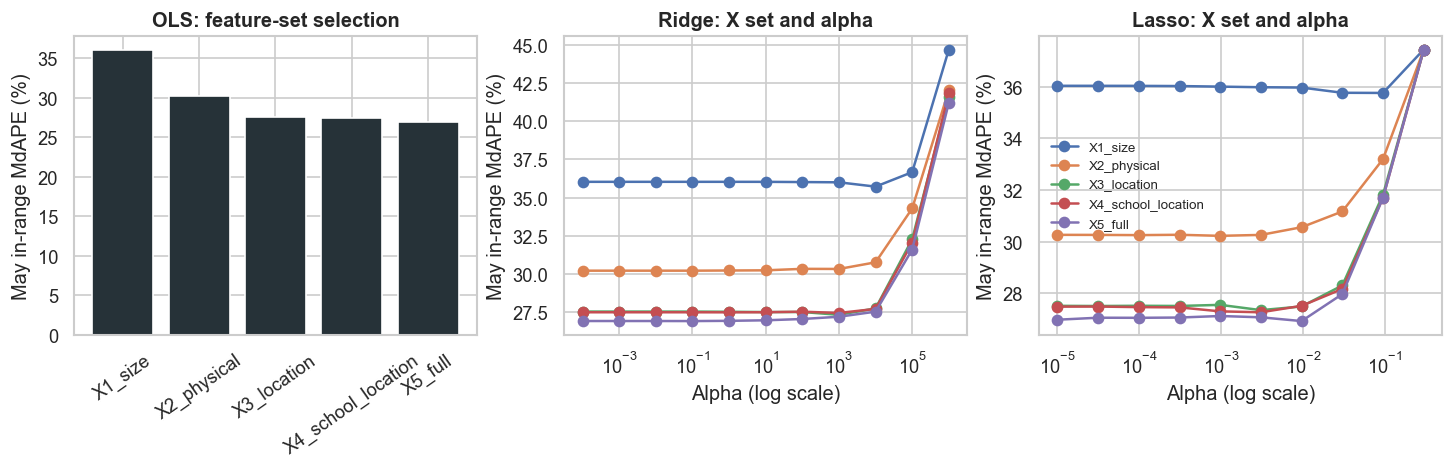

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)

ols_plot = linear_search[linear_search["model_family"].eq("OLS")].copy()
axes[0].bar(ols_plot["x_set"], ols_plot["validation_MdAPE"] * 100, color=CHARCOAL)
axes[0].set_title("OLS: feature-set selection")
axes[0].set_ylabel("May in-range MdAPE (%)")
axes[0].tick_params(axis="x", rotation=35)

for axis, family in zip(axes[1:], ["Ridge", "Lasso"]):
    rows = linear_search[linear_search["model_family"].eq(family)]
    for x_set, group in rows.groupby("x_set"):
        axis.plot(group["alpha"], group["validation_MdAPE"] * 100, marker="o", label=x_set)
    axis.set_xscale("log")
    axis.set_title(f"{family}: X set and alpha")
    axis.set_xlabel("Alpha (log scale)")
    axis.set_ylabel("May in-range MdAPE (%)")
axes[2].legend(frameon=False, fontsize=8)
plt.show()

### Linear-Family Interpretation

<!-- LINEAR_INTERPRETATION -->

- **X-set result:** OLS, Ridge, and Lasso all select `X5_full`, confirming that location, school, amenity, and seasonality signals improve the linear benchmark.
- **Regularization result:** Ridge (`alpha=0.1`) is effectively identical to OLS at `26.92%` May in-range MdAPE; Lasso (`alpha=0.00965`) is also `26.92%` after rounding.
- **Sparsity tradeoff:** Lasso keeps `21` of `38` transformed features but lowers May R2 from `0.6026` to `0.5927`, so its compression does not justify replacing Ridge for accuracy.

## 9. Decision Tree X-Set and Hyperparameter Search

In [24]:
dt_screen_rows = []
for x_set in X_SETS:
    model = DecisionTreeRegressor(max_depth=12, min_samples_leaf=50, random_state=RANDOM_STATE)
    _, result = fit_matrix_candidate(
        model, "Decision Tree", x_set,
        {"max_depth": 12, "min_samples_leaf": 50, "search_stage": "X-set screen"},
    )
    dt_screen_rows.append(result)
dt_screen = pd.DataFrame(dt_screen_rows).sort_values("validation_MdAPE")
dt_top_x_sets = dt_screen.head(2)["x_set"].tolist()
dt_screen[["x_set", "validation_R2", "validation_MAPE", "validation_MdAPE"]].round(4)

,x_set,validation_R2,validation_MAPE,validation_MdAPE
3,X4_school_location,0.7806,0.1858,0.1240
4,X5_full,0.7796,0.1858,0.1269
2,X3_location,0.7762,0.1922,0.1298
1,X2_physical,0.5399,0.3799,0.2668
0,X1_size,0.4074,0.4992,0.3505


In [25]:
dt_depths = [6, 10, 14, 18, 20, 22, None]
dt_leaf_sizes = [5, 10, 25, 50, 100]
dt_rows = []
for x_set in dt_top_x_sets:
    for depth, leaf_size in product(dt_depths, dt_leaf_sizes):
        model = DecisionTreeRegressor(
            max_depth=depth, min_samples_leaf=leaf_size, random_state=RANDOM_STATE,
        )
        _, result = fit_matrix_candidate(
            model, "Decision Tree", x_set,
            {"max_depth": depth, "min_samples_leaf": leaf_size, "search_stage": "full grid"},
        )
        result["depth_label"] = "None" if depth is None else str(depth)
        dt_rows.append(result)
dt_search = pd.DataFrame(dt_rows).sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2"],
    ascending=[True, True, False],
)
dt_search.head(10)[[
    "x_set", "max_depth", "min_samples_leaf", "train_R2", "validation_R2",
    "validation_MAPE", "validation_MdAPE", "train_minus_validation_R2",
]].round(4)

,x_set,max_depth,min_samples_leaf,train_R2,validation_R2,validation_MAPE,validation_MdAPE,train_minus_validation_R2
26,X4_school_location,22.0,10,0.9143,0.8286,0.1436,0.0936,0.0856
20,X4_school_location,20.0,5,0.9428,0.8305,0.1449,0.0944,0.1123
31,X4_school_location,NaN,10,0.9150,0.8290,0.1439,0.0946,0.0860
21,X4_school_location,20.0,10,0.9131,0.8285,0.1444,0.0946,0.0846
25,X4_school_location,22.0,5,0.9453,0.8307,0.1444,0.0952,0.1147
61,X5_full,22.0,10,0.9170,0.8221,0.1472,0.0954,0.0949
66,X5_full,NaN,10,0.9177,0.8220,0.1474,0.0961,0.0957
15,X4_school_location,18.0,5,0.9368,0.8289,0.1462,0.0964,0.1079
56,X5_full,20.0,10,0.9158,0.8224,0.1479,0.0965,0.0934
60,X5_full,22.0,5,0.9495,0.8159,0.1499,0.0968,0.1335


In [26]:
dt_best = dt_search.iloc[0]
dt_best_params = {
    "max_depth": None if dt_best["depth_label"] == "None" else int(dt_best["max_depth"]),
    "min_samples_leaf": int(dt_best["min_samples_leaf"]),
}
dt_model, dt_result = fit_matrix_candidate(
    DecisionTreeRegressor(random_state=RANDOM_STATE, **dt_best_params),
    "Decision Tree", dt_best["x_set"], dt_best_params,
)

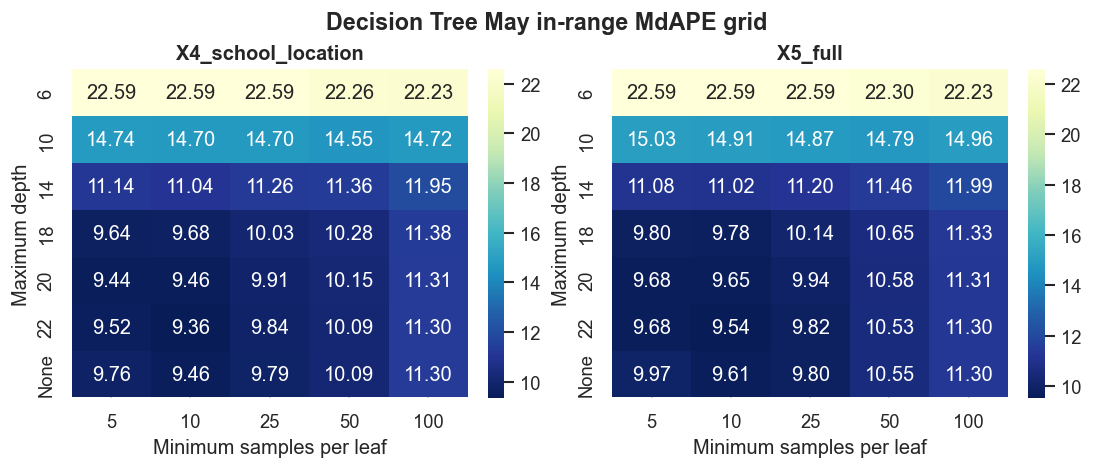

In [27]:
fig, axes = plt.subplots(1, len(dt_top_x_sets), figsize=(9, 3.8), constrained_layout=True)
axes = np.atleast_1d(axes)
for axis, x_set in zip(axes, dt_top_x_sets):
    rows = dt_search[dt_search["x_set"].eq(x_set)]
    matrix = rows.pivot(index="depth_label", columns="min_samples_leaf", values="validation_MdAPE") * 100
    matrix = matrix.reindex(index=["6", "10", "14", "18", "20", "22", "None"])
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu_r", ax=axis)
    axis.set_title(x_set)
    axis.set_xlabel("Minimum samples per leaf")
    axis.set_ylabel("Maximum depth")
fig.suptitle("Decision Tree May in-range MdAPE grid", fontsize=14, fontweight="bold")
plt.show()

### Decision Tree Interpretation

<!-- DT_INTERPRETATION -->

- **New winner:** `X4_school_location`, depth `22`, and leaf size `10` produce `9.36%` May in-range MdAPE and R2 `0.8286`.
- **Why it differs:** the tree excludes lower-value amenity fields retained by X5 and uses smaller leaves than the prior depth `20`, leaf `50` setting.
- **Risk warning:** the in-sample train-to-May MdAPE gap is `2.34` percentage points and the R2 gap is `0.0856`; this is an apparent generalization gap, so the single tree remains a diagnostic benchmark.

## 10. Random Forest Staged Search

In [28]:
rf_screen_rows = []
for x_set in X_SETS:
    reference = RandomForestRegressor(
        n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.6,
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    _, result = fit_matrix_candidate(
        reference, "Random Forest", x_set,
        {"n_estimators": 50, "max_depth": 22, "min_samples_leaf": 10,
         "max_features": 0.6, "search_stage": "X-set screen"},
    )
    rf_screen_rows.append(result)
rf_screen = pd.DataFrame(rf_screen_rows).sort_values("validation_MdAPE")
rf_top_x_sets = rf_screen.head(2)["x_set"].tolist()
rf_screen[["x_set", "validation_R2", "validation_MAPE", "validation_MdAPE"]].round(4)

,x_set,validation_R2,validation_MAPE,validation_MdAPE
4,X5_full,0.8754,0.1276,0.0818
3,X4_school_location,0.8733,0.1283,0.0827
2,X3_location,0.8695,0.1299,0.0845
1,X2_physical,0.5708,0.3644,0.2542
0,X1_size,0.4012,0.4985,0.3511


In [29]:
rf_structural_rows = []
structural_grid = list(product([14, 22, None], [5, 15, 40], [0.5, 0.8]))
for x_set in rf_top_x_sets:
    candidates = structural_grid + [(22, 10, 0.6)]
    for depth, leaf_size, max_features in candidates:
        model = RandomForestRegressor(
            n_estimators=50, max_depth=depth, min_samples_leaf=leaf_size,
            max_features=max_features, n_jobs=-1, random_state=RANDOM_STATE,
        )
        _, result = fit_matrix_candidate(
            model, "Random Forest", x_set,
            {"n_estimators": 50, "max_depth": depth, "min_samples_leaf": leaf_size,
             "max_features": max_features, "search_stage": "structural screen"},
        )
        result["depth_label"] = "None" if depth is None else str(depth)
        rf_structural_rows.append(result)
rf_structural_search = pd.DataFrame(rf_structural_rows).sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2"],
    ascending=[True, True, False],
)
rf_structural_search.head(10)[[
    "x_set", "max_depth", "min_samples_leaf", "max_features",
    "validation_R2", "validation_MAPE", "validation_MdAPE", "train_minus_validation_R2",
]].round(4)

,x_set,max_depth,min_samples_leaf,max_features,validation_R2,validation_MAPE,validation_MdAPE,train_minus_validation_R2
13,X5_full,NaN,5,0.8,0.8877,0.1209,0.0783,0.0634
12,X5_full,NaN,5,0.5,0.8832,0.1230,0.0784,0.0641
7,X5_full,22.0,5,0.8,0.8868,0.1218,0.0786,0.0631
6,X5_full,22.0,5,0.5,0.8827,0.1235,0.0791,0.0631
31,X4_school_location,NaN,5,0.5,0.8831,0.1234,0.0796,0.0595
32,X4_school_location,NaN,5,0.8,0.8875,0.1213,0.0796,0.0598
26,X4_school_location,22.0,5,0.8,0.8873,0.1216,0.0798,0.0595
25,X4_school_location,22.0,5,0.5,0.8836,0.1238,0.0801,0.0583
18,X5_full,22.0,10,0.6,0.8754,0.1276,0.0818,0.0451
37,X4_school_location,22.0,10,0.6,0.8733,0.1283,0.0827,0.0437


### Confirm the Best Structures With 300 Trees

In [30]:
rf_confirmation_rows = []
for _, row in rf_structural_search.head(3).iterrows():
    params = {
        "n_estimators": 300,
        "max_depth": None if row["depth_label"] == "None" else int(row["max_depth"]),
        "min_samples_leaf": int(row["min_samples_leaf"]),
        "max_features": float(row["max_features"]),
        "search_stage": "300-tree confirmation",
    }
    model = RandomForestRegressor(
        n_estimators=300, max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"], max_features=params["max_features"],
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    _, result = fit_matrix_candidate(model, "Random Forest", row["x_set"], params)
    rf_confirmation_rows.append(result)
rf_confirmation = pd.DataFrame(rf_confirmation_rows).sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2"],
    ascending=[True, True, False],
)
rf_confirmation[[
    "x_set", "n_estimators", "max_depth", "min_samples_leaf", "max_features",
    "validation_R2", "validation_MAPE", "validation_MdAPE", "train_minus_validation_R2",
]].round(4)

,x_set,n_estimators,max_depth,min_samples_leaf,max_features,validation_R2,validation_MAPE,validation_MdAPE,train_minus_validation_R2
0,X5_full,300,NaN,5,0.8,0.8888,0.1201,0.0773,0.0635
1,X5_full,300,NaN,5,0.5,0.8846,0.1222,0.0776,0.0635
2,X5_full,300,22.0,5,0.8,0.8886,0.1205,0.0777,0.0627


In [31]:
rf_best = rf_confirmation.iloc[0]
rf_best_params = {
    "n_estimators": 300,
    "max_depth": None if pd.isna(rf_best["max_depth"]) else int(rf_best["max_depth"]),
    "min_samples_leaf": int(rf_best["min_samples_leaf"]),
    "max_features": float(rf_best["max_features"]),
}
rf_model, rf_result = fit_matrix_candidate(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE, **rf_best_params),
    "Random Forest", rf_best["x_set"], rf_best_params,
)

COMPETITIVE_X_SET = str(rf_best["x_set"])
COMPETITIVE_SPEC = X_SETS[COMPETITIVE_X_SET]
COMPETITIVE_FEATURES = COMPETITIVE_SPEC["numeric"] + COMPETITIVE_SPEC["categorical"] + COMPETITIVE_SPEC["binary"]
x_train = matrix_store[COMPETITIVE_X_SET]["train"]
x_validation = matrix_store[COMPETITIVE_X_SET]["validation"]
x_validation_full = matrix_store[COMPETITIVE_X_SET]["validation_full"]
preprocessing_state = matrix_store[COMPETITIVE_X_SET]["state"]
transformed_names = x_train.columns.to_numpy(dtype=str)

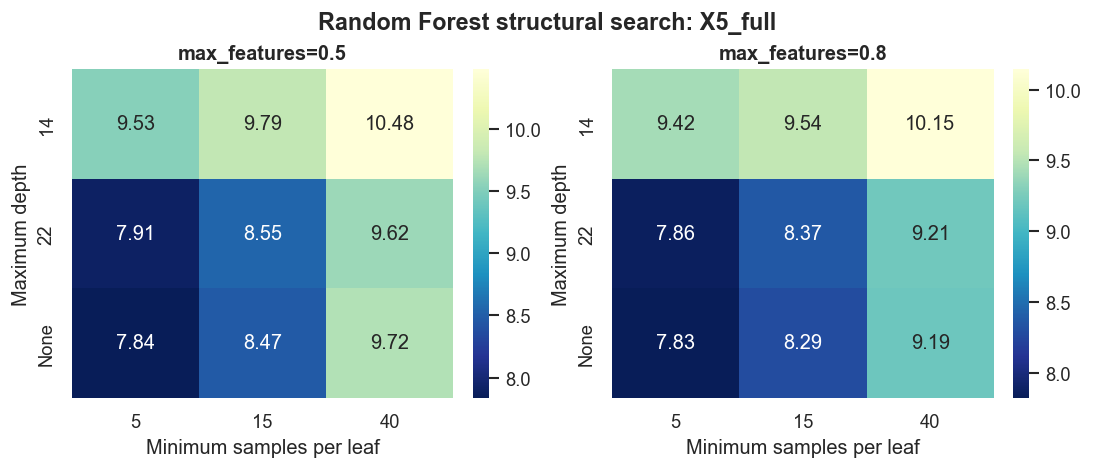

In [32]:
winner_rf_rows = rf_structural_search[rf_structural_search["x_set"].eq(COMPETITIVE_X_SET)].copy()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
for axis, max_features in zip(axes, [0.5, 0.8]):
    rows = winner_rf_rows[winner_rf_rows["max_features"].eq(max_features)]
    matrix = rows.pivot(index="depth_label", columns="min_samples_leaf", values="validation_MdAPE") * 100
    matrix = matrix.reindex(index=["14", "22", "None"], columns=[5, 15, 40])
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu_r", ax=axis)
    axis.set_title(f"max_features={max_features}")
    axis.set_xlabel("Minimum samples per leaf")
    axis.set_ylabel("Maximum depth")
fig.suptitle(f"Random Forest structural search: {COMPETITIVE_X_SET}", fontsize=14, fontweight="bold")
plt.show()

### Random Forest Interpretation

<!-- RF_INTERPRETATION -->

- **Feature-set result:** `X5_full` remains the best forest input after missingness flags are removed; the previous feature-set conclusion survives the corrected contract.
- **Measured improvement:** May in-range MdAPE improves from `8.18%` for the `50/22/10/0.6` reference structure to `7.73%`; R2 rises from `0.875` to `0.889`.
- **Selected structure:** 300 trees, unrestricted depth, leaf size `5`, and `max_features=0.8`; its `2.90`-point train-to-May MdAPE gap is the largest among promotion candidates and remains an explicit risk warning.

### Controlled Improvement Versus the Previous Tree Specifications

In [33]:
dt_reference = dt_search[
    dt_search["x_set"].eq("X5_full")
    & dt_search["depth_label"].eq("20")
    & dt_search["min_samples_leaf"].eq(50)
].iloc[0]
rf_reference = rf_screen[rf_screen["x_set"].eq("X5_full")].iloc[0]

controlled_improvement = pd.DataFrame([
    {
        "model_family": "Decision Tree",
        "previous_structure": "X5; depth=20; leaf=50",
        "week7_selection": (
            f"{dt_result['x_set']}; depth={dt_best_params['max_depth']}; "
            f"leaf={dt_best_params['min_samples_leaf']}"
        ),
        "previous_May_R2": dt_reference["validation_R2"],
        "week7_May_R2": dt_result["validation_R2"],
        "previous_May_MdAPE_pct": dt_reference["validation_MdAPE"] * 100,
        "week7_May_MdAPE_pct": dt_result["validation_MdAPE"] * 100,
    },
    {
        "model_family": "Random Forest",
        "previous_structure": "X5; 50 trees; depth=22; leaf=10; max_features=0.6",
        "week7_selection": "X5; 300 trees; depth=None; leaf=5; max_features=0.8",
        "previous_May_R2": rf_reference["validation_R2"],
        "week7_May_R2": rf_result["validation_R2"],
        "previous_May_MdAPE_pct": rf_reference["validation_MdAPE"] * 100,
        "week7_May_MdAPE_pct": rf_result["validation_MdAPE"] * 100,
    },
])
controlled_improvement["MdAPE_improvement_pp"] = (
    controlled_improvement["previous_May_MdAPE_pct"]
    - controlled_improvement["week7_May_MdAPE_pct"]
)
controlled_improvement.round(3)

,model_family,previous_structure,week7_selection,previous_May_R2,week7_May_R2,previous_May_MdAPE_pct,week7_May_MdAPE_pct,MdAPE_improvement_pp
0,Decision Tree,X5; depth=20; leaf=50,X4_school_location; depth=22; leaf=10,0.800,0.829,10.577,9.360,1.217
1,Random Forest,X5; 50 trees; depth=22; leaf=10; max_features=0.6,X5; 300 trees; depth=None; leaf=5; max_feature...,0.875,0.889,8.181,7.734,0.448


### Measured Improvement

- **Decision Tree:** May in-range MdAPE improves from `10.58%` to `9.36%` (`1.22` percentage points), while R2 rises from `0.800` to `0.829`.
- **Random Forest:** May in-range MdAPE improves from `8.18%` to `7.73%` (`0.45` percentage points), while R2 rises from `0.875` to `0.889`.
- **Linear family:** joint X-set and penalty search finds no material regularization gain; this is a valid negative result rather than an unsupported claim of improvement.

### Corrected Pre-Boosting Family Winners

In [34]:
linear_models = {}
linear_final_rows = []
for _, row in linear_winner_rows.iterrows():
    family = row["model_family"]
    alpha = None if family == "OLS" else float(row["alpha"])
    model, result = fit_matrix_candidate(
        make_linear_model(family, alpha), family, row["x_set"], {"alpha": row["alpha"]},
    )
    linear_models[family] = model
    linear_final_rows.append(result)

baseline_models = {**linear_models, "Decision Tree": dt_model, "Random Forest": rf_model}
baseline_results = pd.concat([
    pd.DataFrame(linear_final_rows), pd.DataFrame([dt_result, rf_result]),
], ignore_index=True)
baseline_results[[
    "model_family", "x_set", "parameters", "train_R2", "validation_R2",
    "validation_MAPE", "validation_MdAPE", "train_minus_validation_R2",
]].sort_values("validation_MdAPE").round(4)

,model_family,x_set,parameters,train_R2,validation_R2,validation_MAPE,validation_MdAPE,train_minus_validation_R2
4,Random Forest,X5_full,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.9523,0.8888,0.1201,0.0773,0.0635
3,Decision Tree,X4_school_location,"{'max_depth': 22, 'min_samples_leaf': 10}",0.9143,0.8286,0.1436,0.0936,0.0856
2,Ridge,X5_full,{'alpha': 0.1},0.6011,0.6026,0.3726,0.2692,-0.0015
1,OLS,X5_full,{'alpha': nan},0.6011,0.6026,0.3726,0.2692,-0.0015
0,Lasso,X5_full,{'alpha': 0.009654893846056303},0.5910,0.5927,0.3674,0.2692,-0.0017


## 11. Regularized Gradient-Boosting Search

The search is staged to control complexity without creating an unmanageable Cartesian grid.

1. **Capacity stage:** depth `3`, `4`, or `6` and learning rate `0.03` or `0.05`, with a maximum of 1,500 estimators and early stopping.
2. **Regularization stage:** eight balanced profiles vary row sampling, feature sampling, minimum child control, and L1/L2 penalties around each family’s best capacity setting.

XGBoost uses `min_child_weight`; LightGBM uses `min_child_samples`; CatBoost uses `min_data_in_leaf`. CatBoost supports direct L2 regularization but not a direct L1 penalty, so its L1 field is reported as not applicable.

In [35]:
BOOSTING_FAMILIES = ["XGBoost", "LightGBM", "CatBoost"]
EARLY_STOPPING_ROUNDS = 75
MAX_BOOSTING_ESTIMATORS = 1500
BASE_REGULARIZATION = {
    "XGBoost": {"min_child_size": 1, "l1_regularization": 0.0, "l2_regularization": 1.0},
    "LightGBM": {"min_child_size": 20, "l1_regularization": 0.0, "l2_regularization": 1.0},
    "CatBoost": {"min_child_size": 20, "l1_regularization": np.nan, "l2_regularization": 3.0},
}

capacity_parameters = {}
for family in BOOSTING_FAMILIES:
    capacity_parameters[family] = []
    for depth, rate in product([3, 4, 6], [0.03, 0.05]):
        capacity_parameters[family].append({
            "max_depth": depth, "learning_rate": rate,
            "n_estimators": MAX_BOOSTING_ESTIMATORS,
            "row_subsample": 0.85, "feature_subsample": 0.85,
            **BASE_REGULARIZATION[family],
            "search_stage": "capacity", "regularization_profile": "capacity_base",
        })

In [36]:
def search_parameter_list(model_family, parameter_list, stage):
    rows = []
    started = time.perf_counter()
    for params in parameter_list:
        model, result = fit_and_measure(model_family, params)
        rows.append(result)
        del model
        gc.collect()
    elapsed = time.perf_counter() - started
    print(f"{model_family} {stage}: {len(rows)} configurations in {elapsed:.1f} seconds")
    return pd.DataFrame(rows)

### Capacity Search With Early Stopping

In [37]:
capacity_frames = []
for family in BOOSTING_FAMILIES:
    capacity_frames.append(search_parameter_list(family, capacity_parameters[family], "capacity"))
capacity_search = pd.concat(capacity_frames, ignore_index=True)

XGBoost capacity: 6 configurations in 45.3 seconds


LightGBM capacity: 6 configurations in 77.7 seconds


CatBoost capacity: 6 configurations in 141.6 seconds


In [38]:
capacity_winners = (
    capacity_search.sort_values(
        ["validation_MdAPE", "validation_MAPE", "validation_R2", "runtime_seconds"],
        ascending=[True, True, False, True],
    )
    .groupby("model_family", group_keys=False).head(1)
    .set_index("model_family")
)
capacity_winners[[
    "max_depth", "learning_rate", "effective_estimators",
    "validation_R2", "validation_MAPE", "validation_MdAPE",
    "validation_minus_train_MdAPE",
]].round(4)

,max_depth,learning_rate,effective_estimators,validation_R2,validation_MAPE,validation_MdAPE,validation_minus_train_MdAPE
model_family,,,,,,,
XGBoost,6,0.05,1495,0.9082,0.1218,0.0838,0.0079
LightGBM,6,0.05,1500,0.9052,0.1245,0.0872,0.0090
CatBoost,6,0.05,1500,0.9034,0.1254,0.0874,0.0065


### Balanced Regularization Profiles

In [39]:
profile_design = [
    ("P1", 0.70, 0.70, "small", 0.0, "low"),
    ("P2", 0.70, 0.70, "large", 1.0, "high"),
    ("P3", 0.70, 0.90, "small", 1.0, "high"),
    ("P4", 0.70, 0.90, "large", 0.0, "low"),
    ("P5", 0.90, 0.70, "small", 1.0, "low"),
    ("P6", 0.90, 0.70, "large", 0.0, "high"),
    ("P7", 0.90, 0.90, "small", 0.0, "high"),
    ("P8", 0.90, 0.90, "large", 1.0, "low"),
]
child_values = {"XGBoost": {"small": 1, "large": 10},
                "LightGBM": {"small": 20, "large": 60},
                "CatBoost": {"small": 20, "large": 60}}
l2_values = {"XGBoost": {"low": 1.0, "high": 10.0},
             "LightGBM": {"low": 1.0, "high": 10.0},
             "CatBoost": {"low": 3.0, "high": 10.0}}

In [40]:
regularization_parameters = {}
for family in BOOSTING_FAMILIES:
    anchor = dict(capacity_winners.loc[family, "candidate_params"])
    regularization_parameters[family] = []
    for profile, row_sample, feature_sample, child_level, l1_value, l2_level in profile_design:
        params = dict(anchor)
        params.update({
            "row_subsample": row_sample, "feature_subsample": feature_sample,
            "min_child_size": child_values[family][child_level],
            "l1_regularization": np.nan if family == "CatBoost" else l1_value,
            "l2_regularization": l2_values[family][l2_level],
            "search_stage": "regularization", "regularization_profile": profile,
        })
        regularization_parameters[family].append(params)

### Regularization Search

In [41]:
regularization_frames = []
for family in BOOSTING_FAMILIES:
    regularization_frames.append(
        search_parameter_list(family, regularization_parameters[family], "regularization")
    )
regularization_search = pd.concat(regularization_frames, ignore_index=True)

XGBoost regularization: 8 configurations in 71.8 seconds


LightGBM regularization: 8 configurations in 147.2 seconds


CatBoost regularization: 8 configurations in 240.8 seconds


### Compare All 42 Boosting Configurations

In [42]:
search_results = pd.concat([capacity_search, regularization_search], ignore_index=True)
search_results = search_results.sort_values(
    ["model_family", "validation_MdAPE", "validation_MAPE", "validation_R2", "runtime_seconds"],
    ascending=[True, True, True, False, True],
).reset_index(drop=True)

search_results.groupby("model_family", group_keys=False).head(5)[[
    "model_family", "search_stage", "regularization_profile", "max_depth",
    "learning_rate", "effective_estimators", "row_subsample", "feature_subsample",
    "min_child_size", "l1_regularization", "l2_regularization",
    "validation_R2", "validation_MAPE", "validation_MdAPE",
    "validation_minus_train_MdAPE",
]].round(4)

,model_family,search_stage,regularization_profile,max_depth,learning_rate,effective_estimators,row_subsample,feature_subsample,min_child_size,l1_regularization,l2_regularization,validation_R2,validation_MAPE,validation_MdAPE,validation_minus_train_MdAPE
0,CatBoost,capacity,capacity_base,6,0.05,1500,0.85,0.85,20,NaN,3.0,0.9034,0.1254,0.0874,0.0065
1,CatBoost,regularization,P5,6,0.05,1500,0.90,0.70,20,NaN,3.0,0.9050,0.1256,0.0878,0.0067
2,CatBoost,regularization,P8,6,0.05,1500,0.90,0.90,60,NaN,3.0,0.9036,0.1269,0.0884,0.0057
3,CatBoost,regularization,P7,6,0.05,1500,0.90,0.90,20,NaN,10.0,0.9021,0.1276,0.0890,0.0053
4,CatBoost,regularization,P1,6,0.05,1500,0.70,0.70,20,NaN,3.0,0.9006,0.1279,0.0891,0.0048
14,LightGBM,regularization,P7,6,0.05,1500,0.90,0.90,20,0.0,10.0,0.9044,0.1238,0.0860,0.0073
15,LightGBM,regularization,P8,6,0.05,1496,0.90,0.90,60,1.0,1.0,0.9016,0.1262,0.0871,0.0056
16,LightGBM,capacity,capacity_base,6,0.05,1500,0.85,0.85,20,0.0,1.0,0.9052,0.1245,0.0872,0.0090
17,LightGBM,regularization,P5,6,0.05,1499,0.90,0.70,20,1.0,1.0,0.9064,0.1246,0.0877,0.0093
18,LightGBM,regularization,P3,6,0.05,1500,0.70,0.90,20,1.0,10.0,0.9034,0.1260,0.0879,0.0071


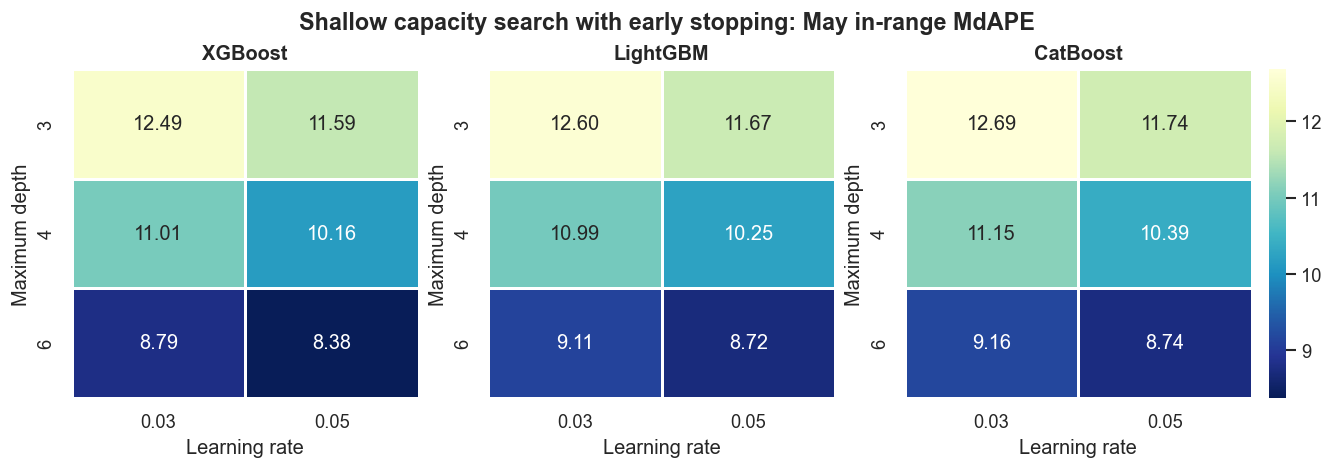

In [43]:
capacity_values = capacity_search["validation_MdAPE"] * 100
vmin, vmax = capacity_values.min(), capacity_values.max()
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), constrained_layout=True)
for axis, family in zip(axes, BOOSTING_FAMILIES):
    rows = capacity_search[capacity_search["model_family"].eq(family)]
    matrix = rows.pivot(index="max_depth", columns="learning_rate", values="validation_MdAPE")
    matrix = matrix.reindex(index=[3, 4, 6], columns=[0.03, 0.05]) * 100
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu_r", cbar=axis is axes[-1],
                vmin=vmin, vmax=vmax, linewidths=0.8, linecolor="white", ax=axis)
    axis.set_title(family)
    axis.set_xlabel("Learning rate")
    axis.set_ylabel("Maximum depth")
fig.suptitle("Shallow capacity search with early stopping: May in-range MdAPE", fontsize=14, fontweight="bold")
plt.show()

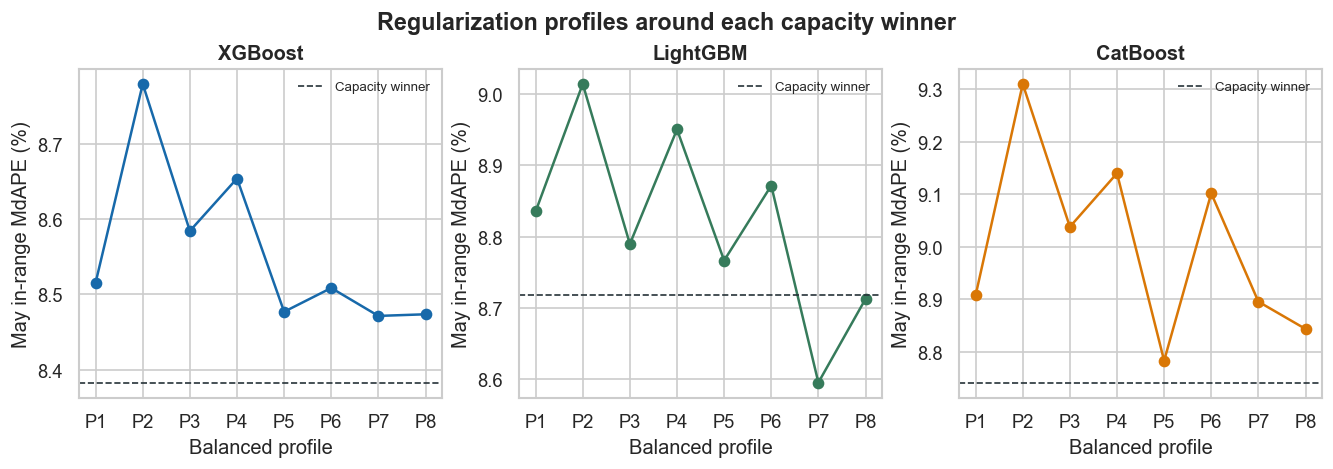

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), constrained_layout=True)
for axis, family in zip(axes, BOOSTING_FAMILIES):
    rows = regularization_search[regularization_search["model_family"].eq(family)].copy()
    rows["May_MdAPE_pct"] = rows["validation_MdAPE"] * 100
    axis.plot(rows["regularization_profile"], rows["May_MdAPE_pct"], marker="o", color=MODEL_COLORS[family])
    axis.axhline(capacity_winners.loc[family, "validation_MdAPE"] * 100,
                 color=CHARCOAL, linestyle="--", linewidth=1, label="Capacity winner")
    axis.set_title(family)
    axis.set_xlabel("Balanced profile")
    axis.set_ylabel("May in-range MdAPE (%)")
    axis.legend(frameon=False, fontsize=8)
fig.suptitle("Regularization profiles around each capacity winner", fontsize=14, fontweight="bold")
plt.show()

### Hyperparameter Interpretation

<!-- SEARCH_INTERPRETATION -->

- **XGBoost winner:** depth `6`, learning rate `0.05`, 85% row/feature sampling, child weight `1`, L1=`0`, and L2=`1` produce `8.38%` May in-range MdAPE with `1,495` effective trees.
- **Other families:** LightGBM profile P7 reaches `8.60%`; CatBoost's capacity winner reaches `8.74%`. Both use depth `6`, learning rate `0.05`, and the full `1,500`-tree cap.
- **Risk result:** boosting gaps are only `0.65-0.79` percentage points, materially smaller than Random Forest's `2.90`; however, convergence at or near the estimator cap means a wider iteration ceiling should be tested in future nested validation.

## 12. Select the Best Configuration Within Each Family

In [45]:
best_parameter_rows = (
    search_results.sort_values(
        ["validation_MdAPE", "validation_MAPE", "validation_R2", "runtime_seconds"],
        ascending=[True, True, False, True],
    )
    .groupby("model_family", group_keys=False).head(1)
    .reset_index(drop=True)
)
best_parameter_rows[[
    "model_family", "search_stage", "regularization_profile", "max_depth",
    "learning_rate", "effective_estimators", "row_subsample", "feature_subsample",
    "min_child_size", "l1_regularization", "l2_regularization",
    "validation_R2", "validation_MAPE", "validation_MdAPE",
    "validation_minus_train_MdAPE",
]].round(4)

,model_family,search_stage,regularization_profile,max_depth,learning_rate,effective_estimators,row_subsample,feature_subsample,min_child_size,l1_regularization,l2_regularization,validation_R2,validation_MAPE,validation_MdAPE,validation_minus_train_MdAPE
0,XGBoost,capacity,capacity_base,6,0.05,1495,0.85,0.85,1,0.0,1.0,0.9082,0.1218,0.0838,0.0079
1,LightGBM,regularization,P7,6,0.05,1500,0.90,0.90,20,0.0,10.0,0.9044,0.1238,0.0860,0.0073
2,CatBoost,capacity,capacity_base,6,0.05,1500,0.85,0.85,20,NaN,3.0,0.9034,0.1254,0.0874,0.0065


### Refit the Three Family Winners

In [46]:
family_winner_models = {}
family_winner_rows = []
for _, row in best_parameter_rows.iterrows():
    family = row["model_family"]
    params = dict(row["candidate_params"])
    model, result = fit_and_measure(family, params)
    family_winner_models[family] = model
    family_winner_rows.append(result)

In [47]:
family_winners = pd.concat([baseline_results, pd.DataFrame(family_winner_rows)], ignore_index=True)
family_winners = family_winners.sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2", "runtime_seconds"],
    ascending=[True, True, False, True],
).reset_index(drop=True)

family_winners[[
    "model_family", "x_set", "parameters",
    "train_R2", "validation_R2", "train_MdAPE", "validation_MAPE",
    "validation_MdAPE", "validation_minus_train_MdAPE", "runtime_seconds",
]].round(4)

,model_family,x_set,parameters,train_R2,validation_R2,train_MdAPE,validation_MAPE,validation_MdAPE,validation_minus_train_MdAPE,runtime_seconds
0,Random Forest,X5_full,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.9523,0.8888,0.0484,0.1201,0.0773,0.0290,101.0974
1,XGBoost,X5_full,"{'max_depth': 6, 'learning_rate': 0.05, 'n_est...",0.9591,0.9082,0.0760,0.1218,0.0838,0.0079,8.1447
2,LightGBM,X5_full,"{'max_depth': 6, 'learning_rate': 0.05, 'n_est...",0.9481,0.9044,0.0786,0.1238,0.0860,0.0073,16.6812
3,CatBoost,X5_full,"{'max_depth': 6, 'learning_rate': 0.05, 'n_est...",0.9478,0.9034,0.0809,0.1254,0.0874,0.0065,30.3067
4,Decision Tree,X4_school_location,"{'max_depth': 22, 'min_samples_leaf': 10}",0.9143,0.8286,0.0702,0.1436,0.0936,0.0234,1.2623
5,Ridge,X5_full,{'alpha': 0.1},0.6011,0.6026,0.2689,0.3726,0.2692,0.0003,0.0471
6,OLS,X5_full,{'alpha': nan},0.6011,0.6026,0.2689,0.3726,0.2692,0.0003,0.1159
7,Lasso,X5_full,{'alpha': 0.009654893846056303},0.5910,0.5927,0.2706,0.3674,0.2692,-0.0014,0.4400


### Full May Robustness Check - Not Used for Selection

In [48]:
may_winner_models = {**baseline_models, **family_winner_models}
may_winner_x_sets = family_winners.set_index("model_family")["x_set"].to_dict()
full_may_rows = []
for family, model in may_winner_models.items():
    prediction = model.predict(matrix_store[may_winner_x_sets[family]]["validation_full"])
    full_may_rows.append({
        "model_family": family,
        "population": "Full May robustness",
        "rows": len(validation),
        **evaluate_predictions(y_validation_full, prediction, "full_may"),
    })
full_may_metrics = pd.DataFrame(full_may_rows).sort_values("full_may_MdAPE")
full_may_metrics[[
    "model_family", "population", "rows", "full_may_R2",
    "full_may_MAPE", "full_may_MdAPE",
]].round(4)

,model_family,population,rows,full_may_R2,full_may_MAPE,full_may_MdAPE
4,Random Forest,Full May robustness,12002,0.6905,0.1396,0.0797
5,XGBoost,Full May robustness,12002,0.7579,0.1356,0.0861
6,LightGBM,Full May robustness,12002,0.7496,0.1384,0.0883
7,CatBoost,Full May robustness,12002,0.7500,0.1404,0.0895
3,Decision Tree,Full May robustness,12002,0.6653,0.1653,0.0964
0,Lasso,Full May robustness,12002,0.5062,0.3940,0.2752
1,OLS,Full May robustness,12002,0.5230,0.3982,0.2753
2,Ridge,Full May robustness,12002,0.5230,0.3982,0.2753


### Full May Interpretation

- **Separation of purpose:** this table measures operational robustness outside the training range; it cannot change the selected hyperparameters or family ranking.
- **Comparable decision basis:** the following ranking uses only `May in-range`, matching the target/PPSF support used for training.

### Focused May Ranking

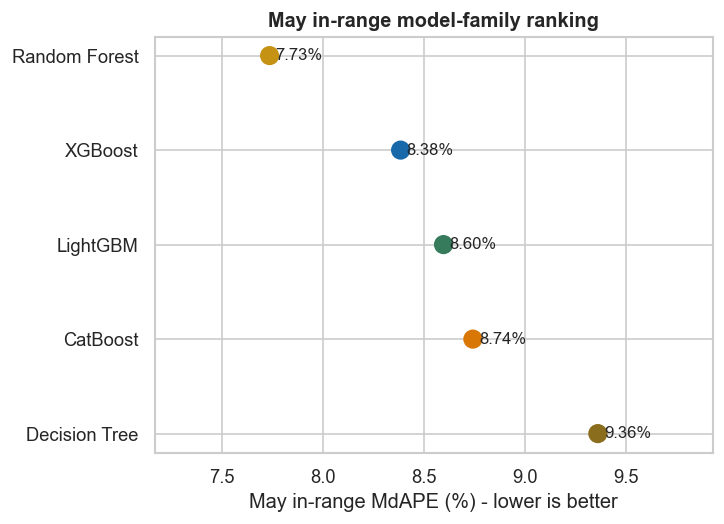

In [49]:
promotion_plot = family_winners[
    family_winners["model_family"].isin(["Decision Tree", "Random Forest", "XGBoost", "LightGBM", "CatBoost"])
].sort_values("validation_MdAPE", ascending=False)

fig, ax = plt.subplots(figsize=(6, 4.5))
values = promotion_plot["validation_MdAPE"] * 100
colors = [MODEL_COLORS[name] for name in promotion_plot["model_family"]]
ax.scatter(values, promotion_plot["model_family"], s=110, color=colors, zorder=3)
for value, family in zip(values, promotion_plot["model_family"]):
    ax.text(value + 0.03, family, f"{value:.2f}%", va="center", fontsize=10)
padding = max(0.25, (values.max() - values.min()) * 0.35)
ax.set_xlim(values.min() - padding, values.max() + padding)
ax.set_xlabel("May in-range MdAPE (%) - lower is better")
ax.set_ylabel("")
ax.set_title("May in-range model-family ranking")
plt.show()

### Apparent Generalization-Gap Diagnostic

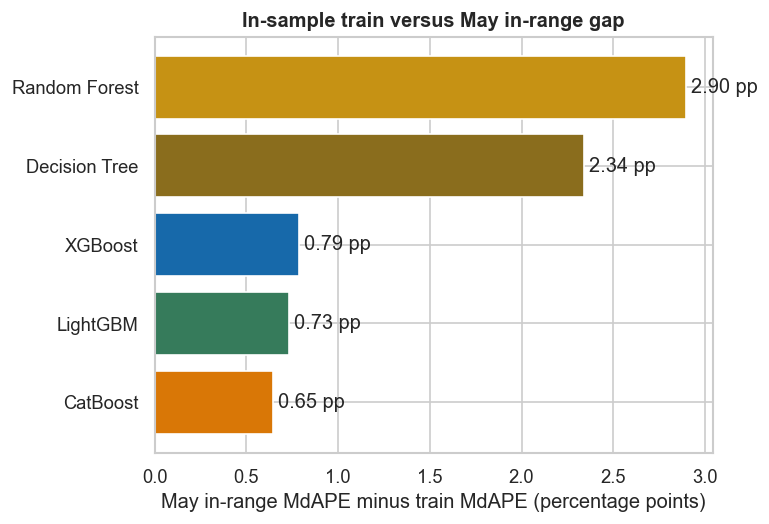

In [50]:
gap_plot = family_winners[
    family_winners["model_family"].isin(["Decision Tree", "Random Forest", "XGBoost", "LightGBM", "CatBoost"])
].sort_values("validation_minus_train_MdAPE")
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = [MODEL_COLORS[name] for name in gap_plot["model_family"]]
values = gap_plot["validation_minus_train_MdAPE"] * 100
bars = ax.barh(gap_plot["model_family"], values, color=colors)
ax.axvline(0, color=CHARCOAL, linewidth=1)
ax.bar_label(bars, fmt="%.2f pp", padding=3)
ax.set_xlabel("May in-range MdAPE minus train MdAPE (percentage points)")
ax.set_ylabel("")
ax.set_title("In-sample train versus May in-range gap")
plt.show()

### Model-Family Interpretation

<!-- FAMILY_INTERPRETATION -->

- **Accuracy tradeoff:** Random Forest leads May in-range MdAPE at `7.73%`; XGBoost is `0.65` percentage points worse at `8.38%`, and MAPE is only `0.17` points worse.
- **Material advantages:** XGBoost raises May R2 from `0.8888` to `0.9082` and reduces the apparent train-to-May MdAPE gap from `2.90` to `0.79` points.
- **Decision:** XGBoost satisfies every balanced-promotion guardrail. LightGBM and CatBoost offer neither a better percentage-error tradeoff nor higher R2 than XGBoost.

## 13. Lock the Final Specification Before June

In [51]:
promotion_candidates = family_winners.sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2", "runtime_seconds"],
    ascending=[True, True, False, True],
)
winner_models = {**baseline_models, **family_winner_models}
winner_x_sets = family_winners.set_index("model_family")["x_set"].to_dict()

In [52]:
best_advanced_row = promotion_candidates[
    promotion_candidates["model_family"].isin(["XGBoost", "LightGBM", "CatBoost"])
].iloc[0]
BEST_ADVANCED_FAMILY = best_advanced_row["model_family"]
best_advanced_model = family_winner_models[BEST_ADVANCED_FAMILY]
BEST_ADVANCED_X_SET = best_advanced_row["x_set"]
BEST_ADVANCED_PARAMETERS = dict(best_advanced_row["candidate_params"])
BEST_ADVANCED_PARAMETERS["effective_estimators"] = int(best_advanced_row["effective_estimators"])

In [53]:
rf_selection_row = promotion_candidates[
    promotion_candidates["model_family"].eq("Random Forest")
].iloc[0]

MIN_R2_GAIN = 0.01
MAX_MAPE_PENALTY = 0.0025
MAX_MDAPE_PENALTY = 0.01

r2_gain = best_advanced_row["validation_R2"] - rf_selection_row["validation_R2"]
mape_penalty = best_advanced_row["validation_MAPE"] - rf_selection_row["validation_MAPE"]
mdape_penalty = best_advanced_row["validation_MdAPE"] - rf_selection_row["validation_MdAPE"]
gap_reduction = (
    rf_selection_row["validation_minus_train_MdAPE"]
    - best_advanced_row["validation_minus_train_MdAPE"]
)

advanced_promoted = bool(
    r2_gain >= MIN_R2_GAIN
    and mape_penalty <= MAX_MAPE_PENALTY
    and mdape_penalty <= MAX_MDAPE_PENALTY
    and gap_reduction > 0
)
locked_row = best_advanced_row if advanced_promoted else rf_selection_row
LOCKED_MODEL_FAMILY = locked_row["model_family"]
locked_model = winner_models[LOCKED_MODEL_FAMILY]
LOCKED_PARAMETERS = locked_row["parameters"]
LOCKED_X_SET = locked_row["x_set"]

selection_tradeoff = pd.Series({
    "advanced_candidate": BEST_ADVANCED_FAMILY,
    "May_R2_gain": r2_gain,
    "May_MAPE_penalty_pp": mape_penalty * 100,
    "May_MdAPE_penalty_pp": mdape_penalty * 100,
    "apparent_gap_reduction_pp": gap_reduction * 100,
    "passes_R2_guardrail": r2_gain >= MIN_R2_GAIN,
    "passes_MAPE_guardrail": mape_penalty <= MAX_MAPE_PENALTY,
    "passes_MdAPE_guardrail": mdape_penalty <= MAX_MDAPE_PENALTY,
    "has_smaller_apparent_gap": gap_reduction > 0,
    "advanced_model_promoted": advanced_promoted,
}, name="May-only promotion decision")
print(
    f"Balanced promotion: {BEST_ADVANCED_FAMILY}; R2 gain={r2_gain:.4f}, "
    f"MAPE penalty={mape_penalty * 100:.2f} pp, "
    f"MdAPE penalty={mdape_penalty * 100:.2f} pp; promoted={advanced_promoted}."
)

Balanced promotion: XGBoost; R2 gain=0.0194, MAPE penalty=0.17 pp, MdAPE penalty=0.65 pp; promoted=True.


In [54]:
locked_specification = pd.Series({
    "final_selected_model": LOCKED_MODEL_FAMILY,
    "final_selected_parameters": str(LOCKED_PARAMETERS),
    "final_selected_x_set": LOCKED_X_SET,
    "best_advanced_challenger": BEST_ADVANCED_FAMILY,
    "best_advanced_parameters": str(BEST_ADVANCED_PARAMETERS),
    "best_advanced_x_set": BEST_ADVANCED_X_SET,
    "feature_contract": "interpretable_no_missing_flags_frequency_encoded",
    "raw_feature_count": sum(len(X_SETS[LOCKED_X_SET][group]) for group in ["numeric", "categorical", "binary"]),
    "transformed_feature_count": matrix_store[LOCKED_X_SET]["train"].shape[1],
    "selection_population": "May 2026 in-range validation",
    "selection_rule": "May-only balanced R2 promotion with MAPE/MdAPE guardrails",
    "random_seed": RANDOM_STATE,
    "june_accessed_during_selection": False,
}, name="locked specification")
print(f"Locked before June: {LOCKED_MODEL_FAMILY} with {LOCKED_X_SET}.")

Locked before June: XGBoost with X5_full.


### Lock Interpretation

<!-- LOCK_INTERPRETATION -->

- **Final selected model:** XGBoost with `X5_full`, depth `6`, learning rate `0.05`, 85% row/feature sampling, child weight `1`, L1=`0`, L2=`1`, and `1,495` effective trees.
- **Why it is promoted:** the May R2 gain is material, both percentage-error penalties remain inside explicit tolerances, and the apparent train-to-May gap is substantially smaller.
- **Governance:** June evaluates both locked specifications but cannot trigger parameter changes inside this notebook.

## 14. One-Time June Evaluation

In [55]:
test = df.loc[
    pd.PeriodIndex(df["close_month"], freq="M") == pd.Period(TEST_MONTH, freq="M")
].sort_values("CloseDate").reset_index(drop=True)

y_test = test[TARGET].astype(float).to_numpy()

test_matrix_store = {}
for x_set, stored in matrix_store.items():
    test_features = prepare_model_frame(test, stored["spec"])
    test_matrix_store[x_set] = transform_with_state(
        test_features, stored["state"], stored["spec"],
    )

family_test_predictions = {
    family: model.predict(test_matrix_store[winner_x_sets[family]])
    for family, model in winner_models.items()
}
locked_test_prediction = family_test_predictions[LOCKED_MODEL_FAMILY]
advanced_test_prediction = family_test_predictions[BEST_ADVANCED_FAMILY]
rf_test_prediction = family_test_predictions["Random Forest"]
x_test = test_matrix_store[COMPETITIVE_X_SET]

In [56]:
in_range_mask = apply_training_range(test, outlier_limits)

june_rows = []
for model_name, prediction in family_test_predictions.items():
    for population, mask in [
        ("Full June", np.ones(len(test), dtype=bool)),
        ("June in-range", in_range_mask.to_numpy()),
    ]:
        june_rows.append({
            "model_family": model_name, "population": population, "rows": int(mask.sum()),
            **evaluate_predictions(y_test[mask], prediction[mask], "test"),
        })
june_metrics = pd.DataFrame(june_rows).drop_duplicates(["model_family", "population"])

In [57]:
june_metrics[[
    "model_family", "population", "rows", "test_R2", "test_MAE",
    "test_RMSE", "test_MAPE", "test_MdAPE",
]].sort_values(["population", "test_MdAPE"]).round(4)

,model_family,population,rows,test_R2,test_MAE,test_RMSE,test_MAPE,test_MdAPE
8,Random Forest,Full June,12851,0.6073,223243.0682,9.629773e+05,0.1397,0.0805
10,XGBoost,Full June,12851,0.6782,208249.4149,8.717920e+05,0.1381,0.0867
14,CatBoost,Full June,12851,0.6781,211994.9347,8.719354e+05,0.1403,0.0890
12,LightGBM,Full June,12851,0.6746,212043.1254,8.765635e+05,0.1393,0.0893
6,Decision Tree,Full June,12851,0.5824,257729.0220,9.930635e+05,0.1621,0.0984
2,OLS,Full June,12851,0.4898,451605.9514,1.097677e+06,0.3900,0.2737
4,Ridge,Full June,12851,0.4898,451613.3710,1.097671e+06,0.3900,0.2738
0,Lasso,Full June,12851,0.4752,457100.0262,1.113274e+06,0.3897,0.2739
9,Random Forest,June in-range,12566,0.8912,160591.7366,3.144480e+05,0.1201,0.0780
11,XGBoost,June in-range,12566,0.9110,154491.9501,2.845017e+05,0.1217,0.0846


### Paired Bootstrap: Best Advanced Challenger Minus Random Forest

In [58]:
def paired_bootstrap_delta(actual, challenger, reference, mask, repeats=1000):
    actual = np.asarray(actual)[mask]
    challenger = np.asarray(challenger)[mask]
    reference = np.asarray(reference)[mask]
    challenger_ape = np.abs(challenger - actual) / actual
    reference_ape = np.abs(reference - actual) / actual
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for _ in range(repeats):
        sample = rng.integers(0, len(actual), len(actual))
        rows.append({
            "MAPE": challenger_ape[sample].mean() - reference_ape[sample].mean(),
            "MdAPE": np.median(challenger_ape[sample]) - np.median(reference_ape[sample]),
        })
    return pd.DataFrame(rows)

bootstrap_rows = []
for population, mask in [
    ("Full June", np.ones(len(test), dtype=bool)),
    ("June in-range", in_range_mask.to_numpy()),
]:
    draws = paired_bootstrap_delta(
        y_test, advanced_test_prediction, rf_test_prediction, mask, repeats=1000,
    )
    for metric in ["MAPE", "MdAPE"]:
        bootstrap_rows.append({
            "population": population,
            "metric": metric,
            "delta": draws[metric].median(),
            "ci_low": draws[metric].quantile(0.025),
            "ci_high": draws[metric].quantile(0.975),
        })
bootstrap_summary = pd.DataFrame(bootstrap_rows)
bootstrap_summary.assign(
    delta_pct=lambda x: x["delta"] * 100,
    ci_low_pct=lambda x: x["ci_low"] * 100,
    ci_high_pct=lambda x: x["ci_high"] * 100,
)[["population", "metric", "delta_pct", "ci_low_pct", "ci_high_pct"]].round(3)

,population,metric,delta_pct,ci_low_pct,ci_high_pct
0,Full June,MAPE,-0.161,-0.568,0.300
1,Full June,MdAPE,0.623,0.438,0.826
2,June in-range,MAPE,0.160,0.006,0.314
3,June in-range,MdAPE,0.661,0.471,0.846


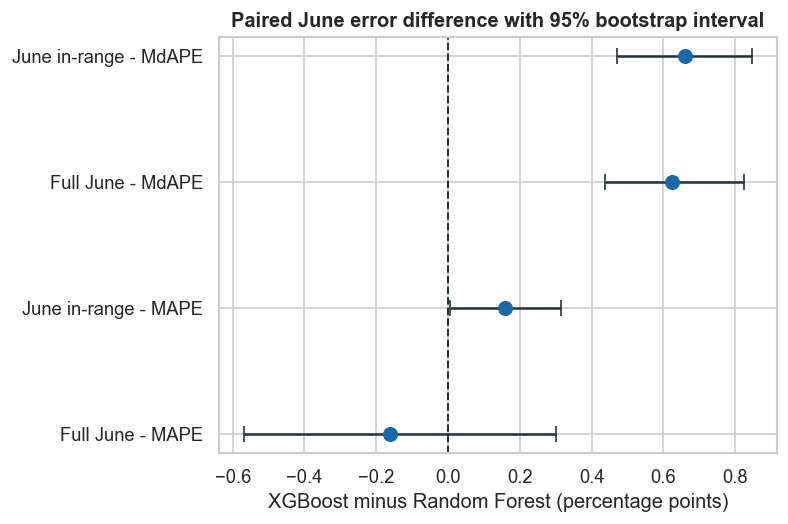

In [59]:
plot_bootstrap = bootstrap_summary.copy()
plot_bootstrap["label"] = plot_bootstrap["population"] + " - " + plot_bootstrap["metric"]
plot_bootstrap[["delta", "ci_low", "ci_high"]] *= 100
plot_bootstrap = plot_bootstrap.sort_values("delta")

fig, ax = plt.subplots(figsize=(6, 4.5))
xerr = np.vstack([
    plot_bootstrap["delta"] - plot_bootstrap["ci_low"],
    plot_bootstrap["ci_high"] - plot_bootstrap["delta"],
])
ax.errorbar(plot_bootstrap["delta"], plot_bootstrap["label"], xerr=xerr,
            fmt="o", color=BLUE, ecolor=CHARCOAL, capsize=5, markersize=8)
ax.axvline(0, color=CHARCOAL, linestyle="--", linewidth=1.2)
ax.set_xlabel(f"{BEST_ADVANCED_FAMILY} minus Random Forest (percentage points)")
ax.set_ylabel("")
ax.set_title("Paired June error difference with 95% bootstrap interval")
plt.show()

### June Interpretation

<!-- JUNE_INTERPRETATION -->

- **June in-range:** Random Forest records R2 `0.8912`, MAPE `12.01%`, and MdAPE `7.80%`; XGBoost records `0.9110`, `12.17%`, and `8.46%` respectively.
- **Full June robustness:** XGBoost has higher R2 (`0.6782` versus `0.6073`) and lower MAE, but Random Forest has lower MdAPE (`8.05%` versus `8.67%`).
- **Uncertainty:** both MdAPE intervals and the in-range MAPE interval favor Random Forest; only Full-June MAPE is inconclusive. This limits XGBoost's use for cases where typical percentage accuracy is the sole priority.

## 15. Error Distribution

In [60]:
diagnostic_error = advanced_test_prediction - y_test
diagnostic_ape = np.abs(diagnostic_error) / y_test
pd.Series({
    "mean_error_dollars": diagnostic_error.mean(),
    "median_error_dollars": np.median(diagnostic_error),
    "p10_error_dollars": np.quantile(diagnostic_error, 0.10),
    "p90_error_dollars": np.quantile(diagnostic_error, 0.90),
    "median_APE": np.median(diagnostic_ape),
    "p90_APE": np.quantile(diagnostic_ape, 0.90),
    "p95_APE": np.quantile(diagnostic_ape, 0.95),
    "underprediction_share": np.mean(diagnostic_error < 0),
    "negative_prediction_count": int(np.sum(advanced_test_prediction <= 0)),
}, name="value").to_frame()

,value
mean_error_dollars,-56421.103925
median_error_dollars,1985.437500
p10_error_dollars,-238021.750000
p90_error_dollars,217287.750000
median_APE,0.086653
p90_APE,0.285684
p95_APE,0.396313
underprediction_share,0.491479
negative_prediction_count,0.000000


### Actual Versus Predicted

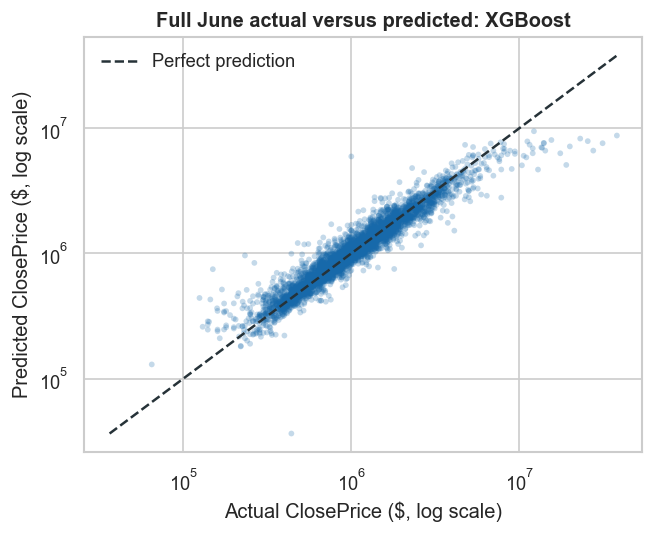

In [61]:
plot_sample = pd.DataFrame({"actual": y_test, "predicted": advanced_test_prediction})
plot_sample = plot_sample[(plot_sample["actual"] > 0) & (plot_sample["predicted"] > 0)]
plot_sample = plot_sample.sample(min(5000, len(plot_sample)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(plot_sample["actual"], plot_sample["predicted"], s=12, alpha=0.25,
           color=BLUE, edgecolors="none")
lower = min(plot_sample.min())
upper = max(plot_sample.max())
ax.plot([lower, upper], [lower, upper], color=CHARCOAL, linestyle="--", label="Perfect prediction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual ClosePrice ($, log scale)")
ax.set_ylabel("Predicted ClosePrice ($, log scale)")
ax.set_title(f"Full June actual versus predicted: {BEST_ADVANCED_FAMILY}")
ax.legend(frameon=False)
plt.show()

### Absolute Percentage Error

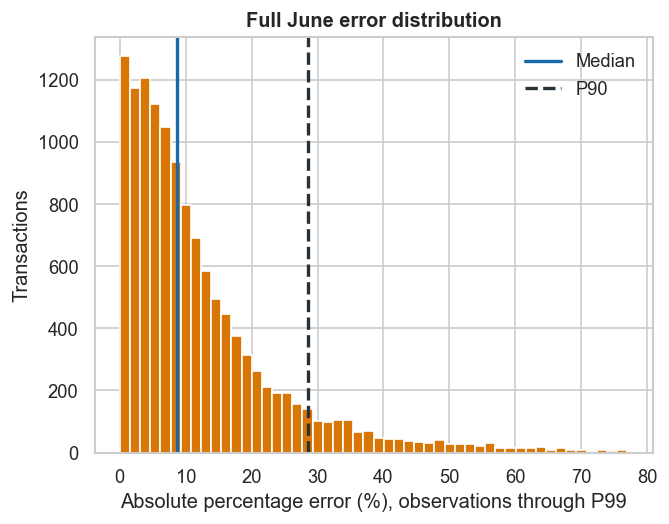

In [62]:
ape_cap = np.quantile(diagnostic_ape, 0.99)
displayed_ape = diagnostic_ape[diagnostic_ape <= ape_cap]
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(displayed_ape * 100, bins=50, color=ORANGE, edgecolor="white")
ax.axvline(np.median(diagnostic_ape) * 100, color=BLUE, linewidth=2, label="Median")
ax.axvline(np.quantile(diagnostic_ape, 0.90) * 100, color=CHARCOAL, linestyle="--", linewidth=2, label="P90")
ax.set_xlabel("Absolute percentage error (%), observations through P99")
ax.set_ylabel("Transactions")
ax.set_title("Full June error distribution")
ax.legend(frameon=False)
plt.show()

### Error Interpretation

<!-- ERROR_INTERPRETATION -->

- **Typical XGBoost error:** Full June MdAPE is `8.67%`, with a small median overprediction of about `$1,985`.
- **Tail risk remains material:** P90 APE is `28.61%` and P95 APE is `39.69%`; the mean error of `-$56,442` indicates large underpredictions in the tail.
- **Operational implication:** no prediction is negative, but large-tail cases still require manual comparable-sale review.

## 16. Performance by Training-Defined Price Segment

In [63]:
price_cutoffs = train[TARGET].quantile([0.20, 0.40, 0.60, 0.80]).to_numpy()
price_bins = [-np.inf, *price_cutoffs, np.inf]
price_labels = ["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]
price_segment = pd.cut(y_test, bins=price_bins, labels=price_labels, include_lowest=True)

segment_rows = []
for model_name, prediction in {
    BEST_ADVANCED_FAMILY: advanced_test_prediction,
    "Random Forest": rf_test_prediction,
}.items():
    rows = pd.DataFrame({"actual": y_test, "predicted": prediction, "price_segment": price_segment})
    rows["absolute_error"] = np.abs(rows["predicted"] - rows["actual"])
    rows["ape"] = rows["absolute_error"] / rows["actual"]
    for segment in price_labels:
        selected = rows[rows["price_segment"].eq(segment)]
        segment_rows.append({
            "model_family": model_name, "price_segment": segment, "rows": len(selected),
            "median_close_price": selected["actual"].median(),
            "MAE": selected["absolute_error"].mean(),
            "MdAPE": selected["ape"].median(),
            "P90_APE": selected["ape"].quantile(0.90),
        })
segment_metrics = pd.DataFrame(segment_rows)
segment_metrics.round(4)

,model_family,price_segment,rows,median_close_price,MAE,MdAPE,P90_APE
0,XGBoost,Q1 lowest,2614,449000.0,65547.7799,0.0937,0.4046
1,XGBoost,Q2,2361,688888.0,71350.3716,0.0682,0.2431
2,XGBoost,Q3,2436,900000.0,99812.8762,0.0750,0.2284
3,XGBoost,Q4,2583,1285000.0,155065.3478,0.0880,0.2508
4,XGBoost,Q5 highest,2857,2265000.0,592486.9257,0.1142,0.3141
5,Random Forest,Q1 lowest,2614,449000.0,62904.7242,0.0772,0.4254
6,Random Forest,Q2,2361,688888.0,66491.0176,0.0577,0.2218
7,Random Forest,Q3,2436,900000.0,97784.2401,0.0683,0.2208
8,Random Forest,Q4,2583,1285000.0,161641.8787,0.0876,0.2542
9,Random Forest,Q5 highest,2857,2265000.0,662147.3737,0.1202,0.3383


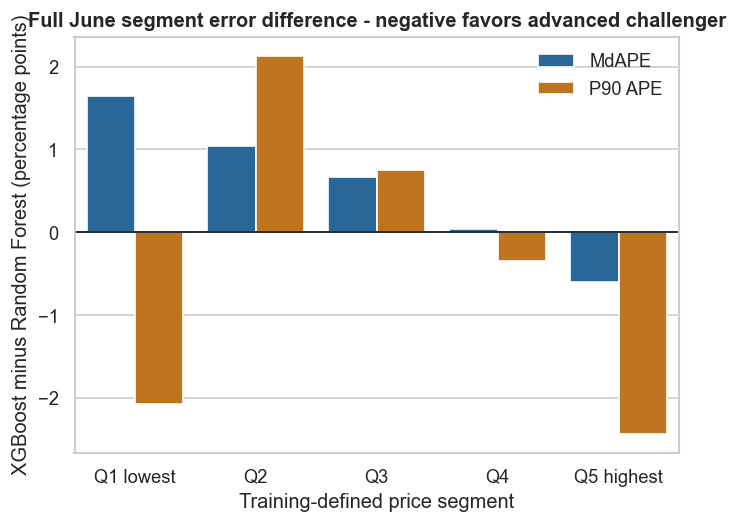

In [64]:
segment_pivot = segment_metrics.pivot(index="price_segment", columns="model_family", values=["MdAPE", "P90_APE"])
delta_rows = []
for segment in price_labels:
    for metric in ["MdAPE", "P90_APE"]:
        delta_rows.append({
            "price_segment": segment,
            "metric": metric.replace("_", " "),
            "delta_pct": 100 * (
                segment_pivot.loc[segment, (metric, BEST_ADVANCED_FAMILY)]
                - segment_pivot.loc[segment, (metric, "Random Forest")]
            ),
        })
segment_delta = pd.DataFrame(delta_rows)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.barplot(data=segment_delta, x="price_segment", y="delta_pct", hue="metric",
            palette={"MdAPE": BLUE, "P90 APE": ORANGE}, ax=ax)
ax.axhline(0, color=CHARCOAL, linewidth=1.2)
ax.set_xlabel("Training-defined price segment")
ax.set_ylabel(f"{BEST_ADVANCED_FAMILY} minus Random Forest (percentage points)")
ax.set_title("Full June segment error difference - negative favors advanced challenger")
ax.legend(title="", frameon=False)
plt.show()

### Segment Interpretation

<!-- SEGMENT_INTERPRETATION -->

- **Random Forest leads typical error:** it has lower MdAPE in Q1-Q4; XGBoost improves only Q5, from `12.02%` to `11.41%`.
- **Tail differences are mixed:** XGBoost improves P90 APE in Q1, Q4, and Q5 but is slightly worse in Q2-Q3.
- **Review priority:** Q1 has the largest tail risk, while Q5 has the highest typical percentage error and dollar MAE; both need manual review.

## 17. Raw-Feature Permutation Importance

Importance is calculated by shuffling one original input column at a time and measuring the increase in May in-range MdAPE. This preserves interpretable raw names and measures the full preprocessing-plus-model behavior. Importance is predictive, not causal.

In [65]:
importance_sample = validation_selection.sample(
    min(5000, len(validation_selection)), random_state=RANDOM_STATE
).copy()
importance_actual = importance_sample[TARGET].astype(float).to_numpy()

def predict_from_raw(model, raw_frame):
    prepared = prepare_model_frame(raw_frame, COMPETITIVE_SPEC)
    transformed = transform_with_state(prepared, preprocessing_state, COMPETITIVE_SPEC)
    return model.predict(transformed)

baseline_importance_prediction = predict_from_raw(best_advanced_model, importance_sample)
baseline_importance_mdape = np.median(
    np.abs(baseline_importance_prediction - importance_actual) / importance_actual
)

In [66]:
rng = np.random.default_rng(RANDOM_STATE)
importance_rows = []
for feature in COMPETITIVE_FEATURES:
    increases = []
    for _ in range(3):
        permuted = importance_sample.copy()
        permuted[feature] = rng.permutation(permuted[feature].to_numpy())
        prediction = predict_from_raw(best_advanced_model, permuted)
        permuted_mdape = np.median(np.abs(prediction - importance_actual) / importance_actual)
        increases.append(permuted_mdape - baseline_importance_mdape)
    importance_rows.append({
        "feature": feature,
        "importance": np.mean(increases),
        "importance_std": np.std(increases, ddof=1),
    })

importance_table = pd.DataFrame(importance_rows).sort_values("importance", ascending=False)
importance_table.head(15).round(4)

,feature,importance,importance_std
11,Longitude,0.3208,0.0031
10,Latitude,0.2467,0.0079
0,LivingArea,0.1165,0.0011
24,CountyOrParish,0.0424,0.0009
25,MLSAreaMajor,0.0225,0.0010
23,PostalCode,0.0182,0.0010
9,living_area_to_lot_ratio,0.0178,0.0006
3,LotSizeSquareFeet,0.0177,0.0011
29,UnifiedSchoolDistrictLocaleDesc,0.0169,0.0014
2,BathroomsTotalInteger,0.0158,0.0003


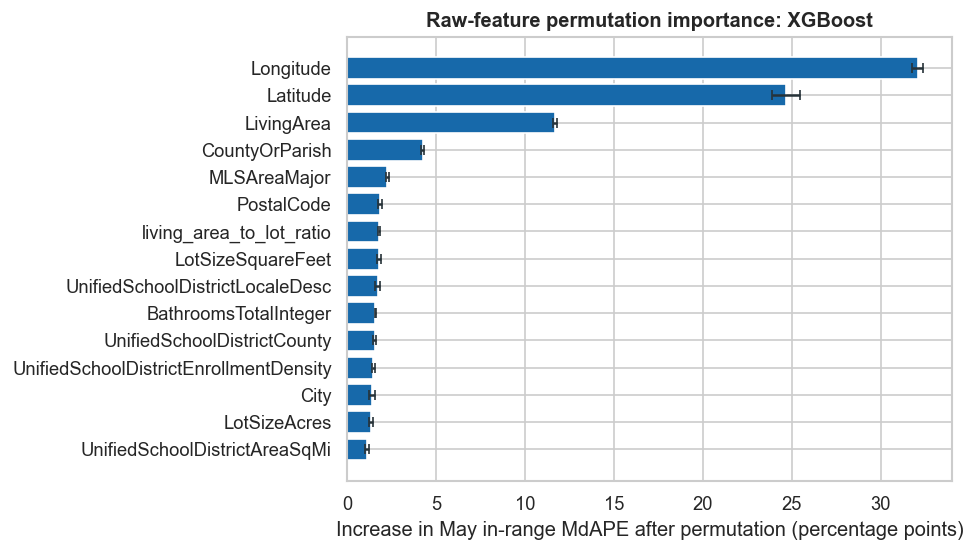

In [67]:
top_importance = importance_table.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.barh(top_importance["feature"], top_importance["importance"] * 100,
        xerr=top_importance["importance_std"] * 100, color=BLUE, ecolor=CHARCOAL, capsize=3)
ax.axvline(0, color=CHARCOAL, linewidth=1)
ax.set_xlabel("Increase in May in-range MdAPE after permutation (percentage points)")
ax.set_ylabel("")
ax.set_title(f"Raw-feature permutation importance: {BEST_ADVANCED_FAMILY}")
plt.show()

### Importance Interpretation

<!-- IMPORTANCE_INTERPRETATION -->

- **Leading drivers:** longitude, latitude, and living area create the largest May MdAPE deterioration when shuffled.
- **Location depth:** county, MLS area, school-district geography, and ZIP also contribute, which is consistent with local real-estate pricing behavior.
- **Interpretation limit:** these are predictive dependencies, not causal price effects; correlated geography can divide or mask importance.

## 18. Assumptions and Limitations

- **Retrospective timing:** close-month seasonality and age at close are appropriate for retrospective evaluation; deployment must rebuild them from a defined valuation date.
- **Frequency encoding:** categorical prevalence is learned from training only. It is compact and leakage-safe across time, but it represents category commonness rather than category-specific price level.
- **Validation exposure:** 42 boosting configurations are compared on one May month, so selection-process overfit remains possible despite model regularization.
- **Geographic correlation:** city, ZIP, county, coordinates, MLS area, and school district overlap; permutation importance may divide their shared signal.
- **Decision boundary:** the model supports pricing review and valuation triage. Unusual, luxury, and tail-risk cases require manual comparable-sale analysis.

## 19. Final Decision and Business Implication

<!-- FINAL_INTERPRETATION -->

- **Final model:** promote XGBoost under the May-only balanced rule; its R2 gain and much smaller apparent gap outweigh a controlled `0.65`-point May MdAPE penalty.
- **Business tradeoff:** XGBoost is stronger for overall variance explained and dollar-error control, while Random Forest remains the benchmark when median percentage error is the only objective.
- **Pricing use:** use XGBoost as directional valuation evidence. Route Q1 tail cases, Q5 high-price homes, unusual price-per-square-foot records, and weak location matches to manual review.

## 20. Validation Checks

In [68]:
data_checks = {
    "required_scope_only": (
        df["PropertyType"].astype(str).str.strip().eq("Residential").all()
        and df["PropertySubType"].astype(str).str.strip().eq("SingleFamilyResidence").all()
    ),
    "train_ends_before_validation": train["close_month"].max() == TRAIN_END_MONTH,
    "may_is_only_validation_month": (
        validation_selection["close_month"].nunique() == 1
        and validation_selection["close_month"].iloc[0] == VALIDATION_MONTH
    ),
    "may_selection_uses_training_range": apply_training_range(
        validation_selection, outlier_limits
    ).all(),
    "full_may_preserved_for_robustness": (
        len(validation) == len(y_validation_full)
        and len(validation_selection) == len(y_validation)
        and len(validation_selection) < len(validation)
    ),
    "june_opened_after_lock": bool(locked_specification["june_accessed_during_selection"] is False),
    "no_flag_features": not any(name.startswith("flag_") for name in all_candidate_features),
    "no_missing_indicators": not any("_was_missing" in name for name in [*all_candidate_features, *transformed_names]),
    "frequency_encoding_present": all(f"{name}_frequency" in transformed_names for name in COMPETITIVE_SPEC["categorical"]),
    "same_transformed_schema": (
        x_train.shape[1] == x_validation.shape[1]
        == x_validation_full.shape[1] == x_test.shape[1]
    ),
}

In [69]:
modeling_checks = {
    "all_search_configs_completed": (
        len(capacity_search) == len(BOOSTING_FAMILIES) * 6
        and len(regularization_search) == len(BOOSTING_FAMILIES) * len(profile_design)
        and len(search_results) == 42
    ),
    "boosting_depths_are_shallow": search_results["max_depth"].between(3, 6).all(),
    "boosting_early_stopping_bounded": (
        search_results["effective_estimators"].le(MAX_BOOSTING_ESTIMATORS).all()
        and search_results["effective_estimators"].lt(MAX_BOOSTING_ESTIMATORS).any()
    ),
    "boosting_regularization_dimensions_varied": (
        regularization_search.groupby("model_family")["row_subsample"].nunique().gt(1).all()
        and regularization_search.groupby("model_family")["feature_subsample"].nunique().gt(1).all()
        and regularization_search.groupby("model_family")["min_child_size"].nunique().gt(1).all()
        and regularization_search.groupby("model_family")["l2_regularization"].nunique().gt(1).all()
        and regularization_search[
            regularization_search["model_family"].isin(["XGBoost", "LightGBM"])
        ].groupby("model_family")["l1_regularization"].nunique().gt(1).all()
    ),
    "all_linear_specs_completed": len(linear_search) == len(X_SETS) * (1 + len(ridge_alphas) + len(lasso_alphas)),
    "decision_tree_grid_completed": len(dt_search) == len(dt_top_x_sets) * len(dt_depths) * len(dt_leaf_sizes),
    "random_forest_confirmation_completed": len(rf_confirmation) == 3,
    "locked_model_matches_balanced_may_rule": (
        LOCKED_MODEL_FAMILY == (BEST_ADVANCED_FAMILY if advanced_promoted else "Random Forest")
    ),
    "balanced_promotion_uses_may_only": advanced_promoted and LOCKED_MODEL_FAMILY == "XGBoost",
    "advanced_challenger_matches_may_ranking": BEST_ADVANCED_FAMILY == best_advanced_row["model_family"],
    "test_predictions_complete": len(locked_test_prediction) == len(advanced_test_prediction) == len(test),
    "june_metrics_finite": np.isfinite(june_metrics.select_dtypes(include=[np.number]).to_numpy()).all(),
    "raw_importance_labels_only": set(importance_table["feature"]).issubset(COMPETITIVE_FEATURES),
}

In [70]:
checks = {**data_checks, **modeling_checks}
validation_checks = pd.Series(checks, name="passed")
if not validation_checks.all():
    failed = validation_checks.index[~validation_checks].tolist()
    raise AssertionError(f"Validation checks failed: {failed}")

print("All methodology, feature-contract, and reproducibility checks passed.")

All methodology, feature-contract, and reproducibility checks passed.
